# Plots 2x2 — lista completa de simulações do sistema aberto

Notebook para carregar os resultados gerados por `run_lista_simulacoes_open_system.py` e plotar, em células separadas, cada conta/caso da lista.

Cada figura 2x2 mostra:

1. non-classicality;
2. coupling $g(t)$;
3. expected value $\langle Z \rangle$;
4. expected value $\langle N \rangle$.

Por padrão, o notebook usa apenas as curvas representativas indicadas no PDF (`zeta_av`, `T_av`, `omega_min`, `omega_av`). Para forçar todas as curvas de cada varredura, mude `SELECTED_ONLY = False` na célula de configuração.

In [1]:
import os
import re
import glob
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (12, 8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

## Configuração

Se quiser usar uma pasta específica, coloque o caminho em `ROOT`. Se deixar `ROOT = None`, o notebook pega automaticamente a pasta `open_system_sims*` mais recente.

In [2]:
BASE = "results/lista_simulacoes_open_system"
ROOT = None

# True: plota apenas os índices representativos pedidos no PDF.
# False: tenta plotar todas as curvas de cada varredura.
SELECTED_ONLY = True

# Salvar automaticamente cada figura quando a célula roda.
SAVE_FIGURES = True
SAVE_PNG = True
SAVE_PDF = True
DPI = 220
FIG_DIR_NAME = "figures_2x2_complete_notebook"

# Mostrar a figura na saída da célula.
SHOW_FIGURES = True

## Localizar resultados

In [3]:
def _root_key(path):
    name = os.path.basename(path)
    m = re.search(r"open_system_sims(\d+)$", name)
    if m:
        return int(m.group(1))
    return -1


def latest_root(base=BASE):
    folders = glob.glob(os.path.join(base, "open_system_sims*"))
    folders = [f for f in folders if os.path.isdir(f)]
    if not folders:
        raise FileNotFoundError(
            "Não encontrei resultados. Rode primeiro: python run_lista_simulacoes_open_system.py"
        )
    return sorted(folders, key=_root_key)[-1]


if ROOT is None:
    ROOT = latest_root()

print("ROOT =", ROOT)
print("Figuras em:", os.path.join(ROOT, FIG_DIR_NAME))

ROOT = results/lista_simulacoes_open_system/open_system_sims1
Figuras em: results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook


## Ler tabela de casos

In [4]:
case_map_path = os.path.join(ROOT, "case_map.csv")
if os.path.exists(case_map_path):
    case_map = pd.read_csv(case_map_path)
else:
    print("Aviso: não achei case_map.csv. As células ainda podem funcionar se as pastas dos casos existirem.")
    case_map = pd.DataFrame(columns=["case_id", "block", "resource", "coupling", "scan_display_name", "n_scan", "tmax", "metric_label"])

display(case_map)

,case_id,block,resource,state_kind,coupling,scan_name,scan_display_name,n_scan,tmax,metric_label,fixed_args,note
0,only_dephasing_wigner_gauss_zeta,only_dephasing,wigner,wigner,gauss,epsilon,zeta,250,15.0,N_W(t),"{""T"": 7.5, ""sigma"": -1.0}",Wigner: gaussian varying width; plotting av in...
1,only_dephasing_wigner_gauss_T,only_dephasing,wigner,wigner,gauss,T,T,100,15.0,N_W(t),"{""epsilon"": 2.4, ""sigma"": -1.0}",Wigner: gaussian varying peak time; plotting a...
2,only_dephasing_wigner_cos_omega,only_dephasing,wigner,wigner,cos,w,omega,100,15.0,N_W(t),"{""phi"": 0.0}",Wigner: cosine varying frequency; plotting min...
3,only_dephasing_coherence_gauss_zeta,only_dephasing,coherence,coherence,gauss,epsilon,zeta,100,50.0,C_q(t),"{""T"": 25.0, ""sigma"": -1.0}",coherence: gaussian varying width; plotting av...
4,only_dephasing_coherence_gauss_T,only_dephasing,coherence,coherence,gauss,T,T,100,50.0,C_q(t),"{""epsilon"": 8.0, ""sigma"": -1.0}",coherence: gaussian varying peak time; plottin...
5,only_dephasing_coherence_cos_omega,only_dephasing,coherence,coherence,cos,w,omega,200,50.0,C_q(t),"{""phi"": 0.0}",coherence: cosine varying frequency; plotting ...
6,only_dephasing_magic_gauss_zeta,only_dephasing,magic,magic,gauss,epsilon,zeta,100,50.0,M_2(t),"{""T"": 25.0, ""sigma"": -1.0}",magic: gaussian varying width; plotting av ind...
7,only_dephasing_magic_gauss_T,only_dephasing,magic,magic,gauss,T,T,100,50.0,M_2(t),"{""epsilon"": 8.0, ""sigma"": -1.0}",magic: gaussian varying peak time; plotting av...
8,only_dephasing_magic_cos_omega,only_dephasing,magic,magic,cos,w,omega,200,50.0,M_2(t),"{""phi"": 0.0}",magic: cosine varying frequency; plotting min ...
9,only_dephasing_entanglement_gauss_zeta,only_dephasing,entanglement,entanglement,gauss,epsilon,zeta,100,50.0,E_N(t),"{""T"": 25.0, ""sigma"": -1.0}",entanglement: gaussian varying width; plotting...


## Funções auxiliares

Essas funções são comuns a todas as células de plot. As células de cada conta, abaixo, só chamam `plot_case_from_cell(...)`.

In [5]:
def case_dir(case_id):
    return os.path.join(ROOT, case_id)


def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_case(case_id):
    folder = case_dir(case_id)
    meta_path = os.path.join(folder, "case_metadata.json")
    t_path = os.path.join(folder, "t.npy")
    args_path = os.path.join(folder, "args_per_scan.csv")
    summary_path = os.path.join(folder, "summary.csv")

    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Não achei a pasta do caso: {folder}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Não achei: {meta_path}")
    if not os.path.exists(t_path):
        raise FileNotFoundError(f"Não achei: {t_path}")
    if not os.path.exists(args_path):
        raise FileNotFoundError(f"Não achei: {args_path}")

    data = {
        "folder": folder,
        "meta": read_json(meta_path),
        "t": np.load(t_path),
        "args": pd.read_csv(args_path),
    }

    if os.path.exists(summary_path):
        data["summary"] = pd.read_csv(summary_path)
    else:
        data["summary"] = None

    return data


def load_metric(folder, label):
    path = os.path.join(folder, f"{label}.npy")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Não achei: {path}")
    return np.load(path)


def load_observables(folder, label):
    path = os.path.join(folder, f"{label}_observables.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Não achei: {path}")
    return pd.read_csv(path)


def clip_indices(indices, n):
    out = []
    for idx in indices:
        idx = int(idx)
        if idx < 0:
            continue
        if idx >= n:
            idx = n - 1
        if idx not in out:
            out.append(idx)
    return out


def selected_scan_indices(meta, args_df):
    n = len(args_df)
    if n == 0:
        return []

    block = str(meta.get("block", ""))
    resource = str(meta.get("resource", ""))
    coupling = str(meta.get("coupling", ""))
    scan_name = str(meta.get("scan_name", ""))

    # Nos casos specific_parameters, o script já rodou exatamente os parâmetros pedidos.
    if block == "specific_parameters":
        return list(range(n))

    # Wigner: t em [0, 15].
    if resource == "wigner":
        if coupling == "gauss" and scan_name == "epsilon":
            return clip_indices([125], n)       # zeta_av: 125+1 no texto -> índice Python 125
        if coupling == "gauss" and scan_name == "T":
            return clip_indices([50], n)        # T_av: 50+1 no texto -> índice Python 50
        if coupling == "cos" or scan_name == "w":
            return clip_indices([25, 50], n)    # omega_min, omega_av

    # Coherence, Magic, Entanglement: t em [0, 50].
    if resource in {"coherence", "magic", "entanglement"}:
        if coupling == "gauss" and scan_name == "epsilon":
            return clip_indices([50], n)        # zeta_av
        if coupling == "gauss" and scan_name == "T":
            return clip_indices([50], n)        # T_av
        if coupling == "cos" or scan_name == "w":
            return clip_indices([50, 100], n)   # omega_min, omega_av

    return clip_indices([n // 2], n)


def safe_log_limits(arrays, floor=1e-12):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        vals.extend(arr[np.isfinite(arr) & (arr > 0)].tolist())
    if not vals:
        return floor, 1.0
    return max(floor, min(vals) * 0.7), max(vals) * 1.3


def use_log_for_metric(resource):
    return resource in {"coherence", "entanglement"}


def metric_name(meta):
    label = meta.get("metric_label")
    if isinstance(label, str) and label.strip():
        return label

    resource = meta.get("resource", "")
    if resource == "wigner":
        return r"$N_W(t)$"
    if resource == "coherence":
        return r"$C_q(t)$"
    if resource == "magic":
        return r"$M_2(t)$"
    if resource == "entanglement":
        return r"$E_N(t)$"
    return "non-classicality"


def format_pi_value(x, tol=1e-8):
    if not np.isfinite(x):
        return "nan"

    candidates = [
        (1 / 20, r"\pi/20"),
        (1 / 10, r"\pi/10"),
        (1 / 6, r"\pi/6"),
        (1 / 5, r"\pi/5"),
        (1 / 3, r"\pi/3"),
        (2 / 3, r"2\pi/3"),
    ]
    for frac, text in candidates:
        if abs(x - frac * np.pi) < tol:
            return f"${text}$"
    return f"{x:.4g}"


def pretty_scan_label(row):
    name = str(row.get("scan_display_name", row.get("scan_name", "param")))
    value = float(row.get("scan_value", np.nan))
    idx = int(row.get("scan_index_python", -1))

    if "omega" in name or str(row.get("scan_name", "")) == "w":
        val = format_pi_value(value)
    else:
        val = f"{value:.4g}"

    return f"{name} = {val}  [i={idx}]"


def get_z_column(df):
    for col in ["expect_Z_qubit", "expect_Z", "expect_Z_global"]:
        if col in df.columns:
            return col
    raise KeyError(
        "Não achei coluna de Z. Esperava uma destas: "
        "expect_Z_qubit, expect_Z, expect_Z_global"
    )


def safe_filename(name):
    keep = []
    for ch in str(name):
        if ch.isalnum() or ch in "._-":
            keep.append(ch)
        else:
            keep.append("_")
    out = "".join(keep)
    while "__" in out:
        out = out.replace("__", "_")
    return out.strip("_")


def rows_to_plot(data, selected_only=SELECTED_ONLY):
    args_df = data["args"].copy()

    if selected_only:
        indices = selected_scan_indices(data["meta"], args_df)
    else:
        indices = list(range(len(args_df)))

    rows = []

    # Curva de referência com acoplamento constante, se existir.
    const_path = os.path.join(data["folder"], "const_aberto.npy")
    const_obs = os.path.join(data["folder"], "const_aberto_observables.csv")
    if os.path.exists(const_path) and os.path.exists(const_obs):
        rows.append({
            "label": "const_aberto",
            "pretty": "constant open",
            "kind": "constant",
            "scan_index_python": -1,
            "scan_index_text_1_based": 0,
            "scan_value": np.nan,
        })

    for idx in indices:
        if idx < 0 or idx >= len(args_df):
            continue

        row = args_df.iloc[int(idx)]
        label = str(row["label"])

        rows.append({
            "label": label,
            "pretty": pretty_scan_label(row),
            "kind": "variable",
            "scan_index_python": int(row.get("scan_index_python", idx)),
            "scan_index_text_1_based": int(row.get("scan_index_text_1_based", idx + 1)),
            "scan_value": float(row.get("scan_value", np.nan)),
        })

    return rows


def selected_curves_table(case_id):
    data = load_case(case_id)
    return pd.DataFrame(rows_to_plot(data))


def plot_case_2x2(case_id, save=SAVE_FIGURES, show=SHOW_FIGURES):
    data = load_case(case_id)
    meta = data["meta"]
    t = data["t"]
    folder = data["folder"]
    resource = meta.get("resource", "")

    rows = rows_to_plot(data)
    if not rows:
        print(f"[skip] {case_id}: nenhuma curva encontrada")
        return None

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12.0, 8.0),
        sharex="col",
        constrained_layout=True,
    )

    ax_metric = axes[0, 0]
    ax_g = axes[0, 1]
    ax_z = axes[1, 0]
    ax_n = axes[1, 1]

    metric_arrays = []
    legend_handles = []
    legend_labels = []
    plotted_rows = []

    for row in rows:
        label = row["label"]
        pretty = row["pretty"]

        try:
            y_metric = load_metric(folder, label)
            obs = load_observables(folder, label)
        except FileNotFoundError as exc:
            print(f"[missing] {case_id} | {label}: {exc}")
            continue

        tt = obs["time"].to_numpy(dtype=float) if "time" in obs.columns else t
        z_col = get_z_column(obs)

        if row["kind"] == "constant":
            style = {"lw": 2.2, "linestyle": "--"}
        else:
            style = {"lw": 1.9}

        line_metric, = ax_metric.plot(t, y_metric, label=pretty, **style)
        ax_g.plot(tt, obs["g_t"].to_numpy(dtype=float), **style)
        ax_z.plot(tt, obs[z_col].to_numpy(dtype=float), **style)
        ax_n.plot(tt, obs["expect_N"].to_numpy(dtype=float), **style)

        metric_arrays.append(y_metric)
        legend_handles.append(line_metric)
        legend_labels.append(pretty)
        plotted_rows.append(row)

    if not plotted_rows:
        plt.close(fig)
        print(f"[skip] {case_id}: arquivos ainda incompletos")
        return None

    if use_log_for_metric(resource):
        ax_metric.set_yscale("log")
        ax_metric.set_ylim(*safe_log_limits(metric_arrays))

    ax_metric.set_ylabel(metric_name(meta))
    ax_metric.set_title("Non-classicality")

    ax_g.set_ylabel(r"$g(t)$")
    ax_g.set_title("Coupling")

    ax_z.set_ylabel(r"$\langle Z \rangle$")
    ax_z.set_title(r"Expected value of $Z$")
    ax_z.set_xlabel("t")

    ax_n.set_ylabel(r"$\langle N \rangle$")
    ax_n.set_title(r"Expected value of $N$")
    ax_n.set_xlabel("t")

    title = (
        f"{meta.get('block', '')} | {meta.get('resource', '')} | "
        f"{meta.get('coupling', '')} | {meta.get('scan_display_name', '')}"
    )
    fig.suptitle(title, fontsize=13)
    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, fontsize=9)

    out_paths = []
    if save:
        fig_dir = os.path.join(ROOT, FIG_DIR_NAME)
        os.makedirs(fig_dir, exist_ok=True)
        base = os.path.join(fig_dir, f"plot_2x2_{safe_filename(case_id)}")

        if SAVE_PNG:
            png = base + ".png"
            fig.savefig(png, dpi=DPI, bbox_inches="tight")
            out_paths.append(png)

        if SAVE_PDF:
            pdf = base + ".pdf"
            fig.savefig(pdf, bbox_inches="tight")
            out_paths.append(pdf)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "case_id": case_id,
        "n_curves": len(plotted_rows),
        "files": ";".join(out_paths),
    }


def plot_case_from_cell(case_id):
    print("case_id =", case_id)
    try:
        display(selected_curves_table(case_id))
        return plot_case_2x2(case_id, save=SAVE_FIGURES, show=SHOW_FIGURES)
    except FileNotFoundError as exc:
        print(f"[skip] {case_id}: {exc}")
        return None

## Resumo rápido dos casos esperados

In [6]:
expected_case_ids = [
    "only_dephasing_wigner_gauss_zeta",
    "only_dephasing_wigner_gauss_T",
    "only_dephasing_wigner_cos_omega",
    "only_dephasing_coherence_gauss_zeta",
    "only_dephasing_coherence_gauss_T",
    "only_dephasing_coherence_cos_omega",
    "only_dephasing_magic_gauss_zeta",
    "only_dephasing_magic_gauss_T",
    "only_dephasing_magic_cos_omega",
    "only_dephasing_entanglement_gauss_zeta",
    "only_dephasing_entanglement_gauss_T",
    "only_dephasing_entanglement_cos_omega",
    "only_cavity_damping_wigner_gauss_zeta",
    "only_cavity_damping_wigner_gauss_T",
    "only_cavity_damping_wigner_cos_omega",
    "only_cavity_damping_coherence_gauss_zeta",
    "only_cavity_damping_coherence_gauss_T",
    "only_cavity_damping_coherence_cos_omega",
    "only_cavity_damping_magic_gauss_zeta",
    "only_cavity_damping_magic_gauss_T",
    "only_cavity_damping_magic_cos_omega",
    "only_cavity_damping_entanglement_gauss_zeta",
    "only_cavity_damping_entanglement_gauss_T",
    "only_cavity_damping_entanglement_cos_omega",
    "specific_parameters_wigner_gauss_zeta_specific",
    "specific_parameters_wigner_gauss_T_specific",
    "specific_parameters_wigner_cos_omega_specific",
    "specific_parameters_coherence_gauss_zeta_specific",
    "specific_parameters_coherence_gauss_T_specific",
    "specific_parameters_coherence_cos_omega_specific",
    "specific_parameters_magic_gauss_zeta_specific",
    "specific_parameters_magic_gauss_T_specific",
    "specific_parameters_magic_cos_omega_specific",
    "specific_parameters_entanglement_gauss_zeta_specific",
    "specific_parameters_entanglement_gauss_T_specific",
    "specific_parameters_entanglement_cos_omega_specific",
]

status_rows = []
for cid in expected_case_ids:
    folder = case_dir(cid)
    status_rows.append({
        "case_id": cid,
        "folder_exists": os.path.isdir(folder),
        "done": os.path.exists(os.path.join(folder, "DONE.txt")),
        "summary": os.path.exists(os.path.join(folder, "summary.csv")),
    })

status = pd.DataFrame(status_rows)
display(status)
print("Casos esperados:", len(status))
print("Pastas encontradas:", int(status["folder_exists"].sum()))
print("Marcados como DONE:", int(status["done"].sum()))

,case_id,folder_exists,done,summary
0,only_dephasing_wigner_gauss_zeta,True,True,True
1,only_dephasing_wigner_gauss_T,True,True,True
2,only_dephasing_wigner_cos_omega,True,True,True
3,only_dephasing_coherence_gauss_zeta,True,True,True
4,only_dephasing_coherence_gauss_T,True,True,True
5,only_dephasing_coherence_cos_omega,True,True,True
6,only_dephasing_magic_gauss_zeta,True,True,True
7,only_dephasing_magic_gauss_T,True,True,True
8,only_dephasing_magic_cos_omega,True,True,True
9,only_dephasing_entanglement_gauss_zeta,True,True,True


Casos esperados: 36
Pastas encontradas: 36
Marcados como DONE: 36


# Only dephasing

$\kappa = 0$, dephasing em `gamma_phi = 1e-3`, `g0 = 1`.

## Wigner — Gaussian width / zeta

`only_dephasing_wigner_gauss_zeta`

case_id = only_dephasing_wigner_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0125_zeta_2p40240963855,zeta = 2.402 [i=125],variable,125,126,2.40241


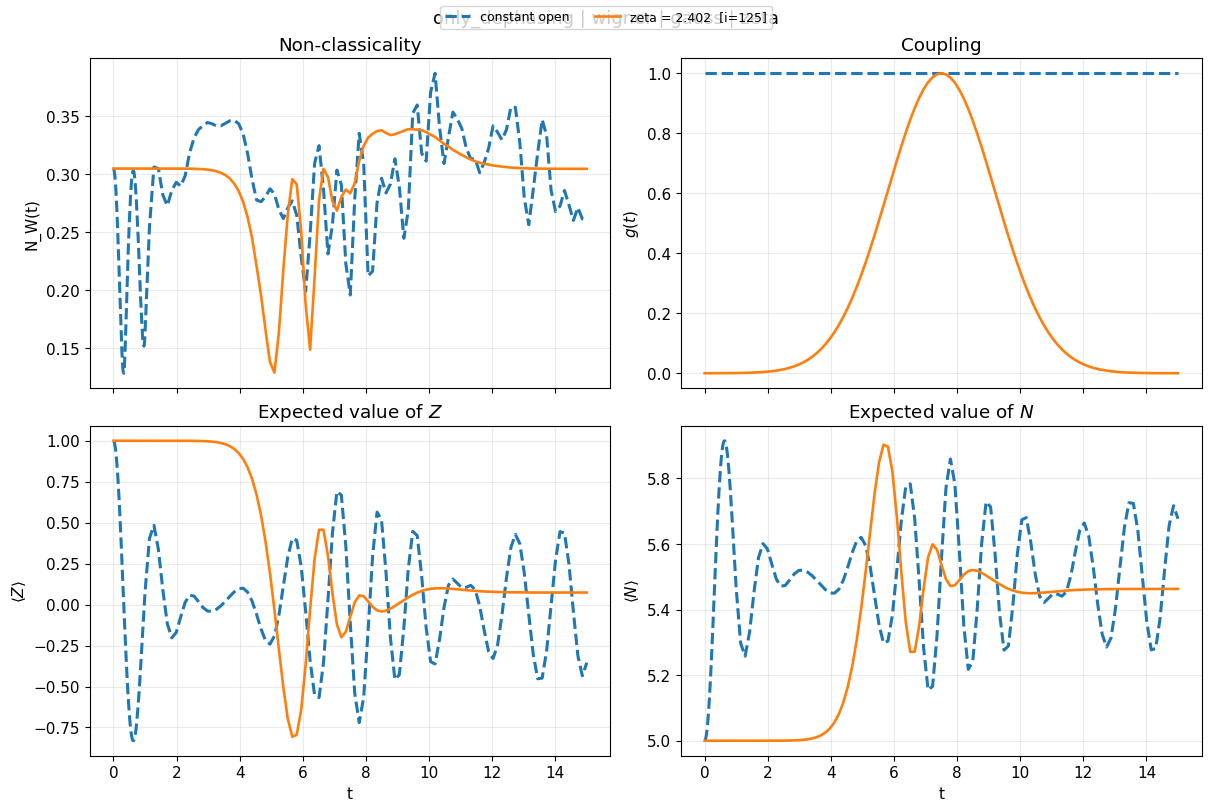

{'case_id': 'only_dephasing_wigner_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_wigner_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_wigner_gauss_zeta.pdf'}

In [7]:
plot_case_from_cell("only_dephasing_wigner_gauss_zeta")

## Wigner — Gaussian peak time / T

`only_dephasing_wigner_gauss_T`

case_id = only_dephasing_wigner_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_7p5303030303,T = 7.53 [i=50],variable,50,51,7.530303


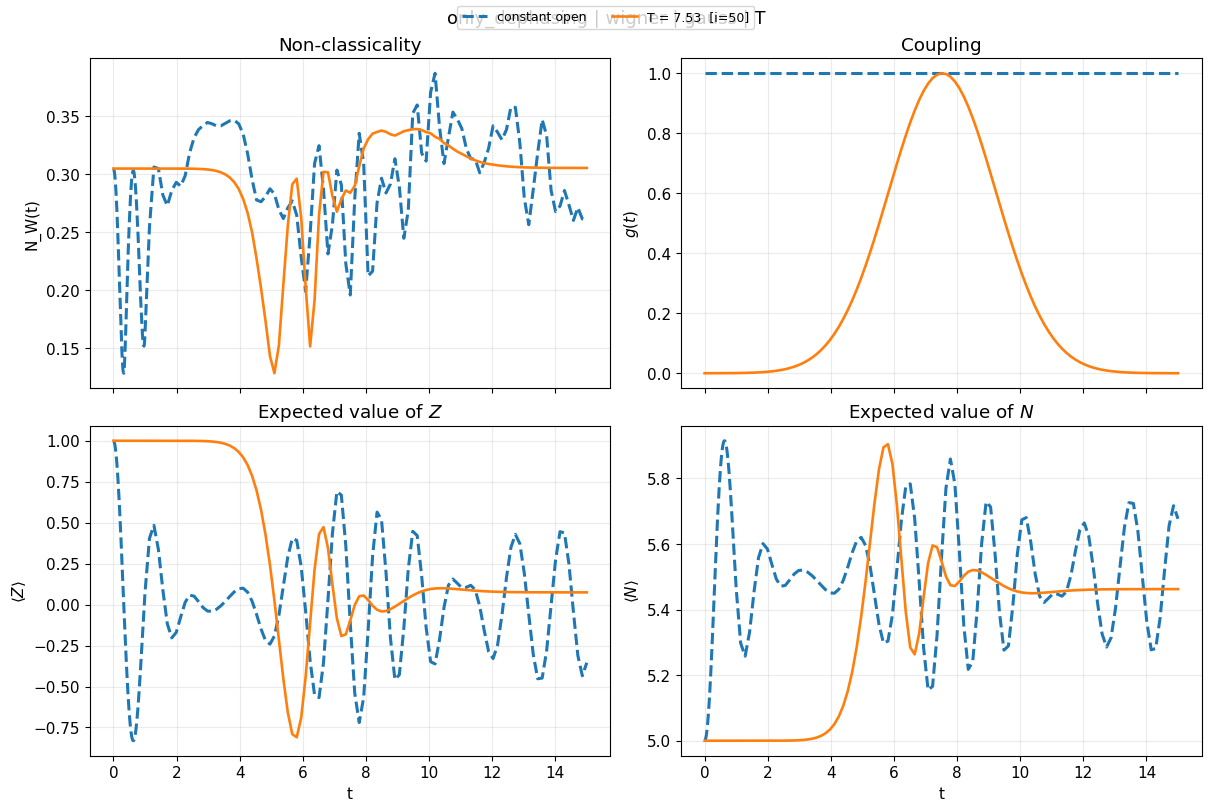

{'case_id': 'only_dephasing_wigner_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_wigner_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_wigner_gauss_T.pdf'}

In [8]:
plot_case_from_cell("only_dephasing_wigner_gauss_T")

## Wigner — Cosine frequency / omega

`only_dephasing_wigner_cos_omega`

case_id = only_dephasing_wigner_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0025_omega_0p528887652119,omega = 0.5289 [i=25],variable,25,26,0.528888
2,var_aberto_0050_omega_1p05777530424,omega = 1.058 [i=50],variable,50,51,1.057775


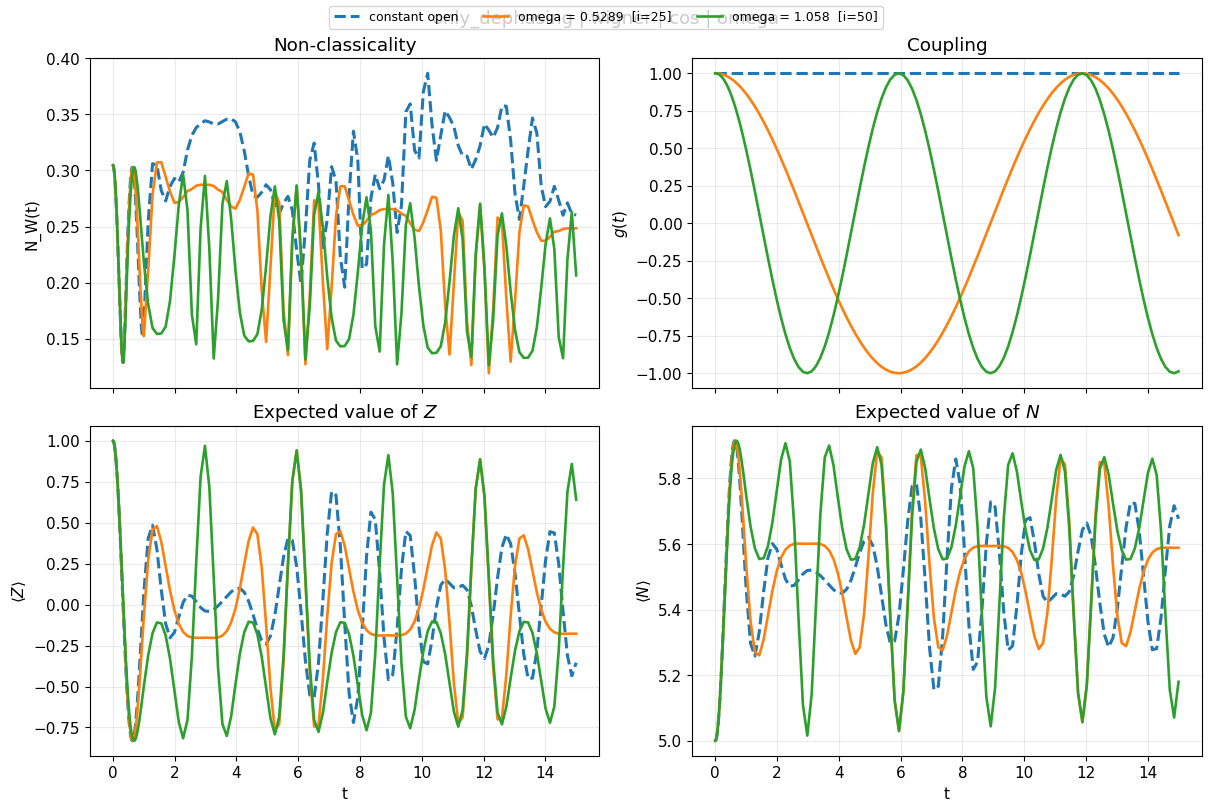

{'case_id': 'only_dephasing_wigner_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_wigner_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_wigner_cos_omega.pdf'}

In [9]:
plot_case_from_cell("only_dephasing_wigner_cos_omega")

## Coherence — Gaussian width / zeta

`only_dephasing_coherence_gauss_zeta`

case_id = only_dephasing_coherence_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_zeta_8p0202020202,zeta = 8.02 [i=50],variable,50,51,8.020202


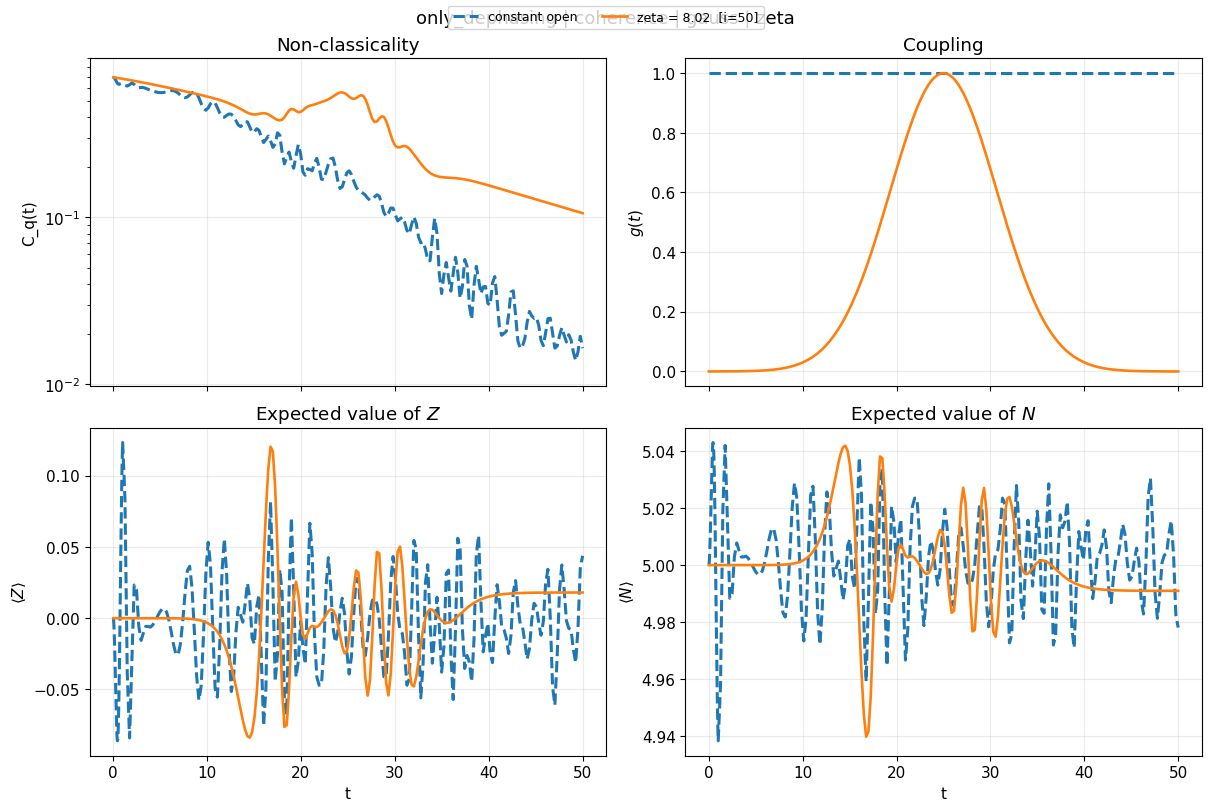

{'case_id': 'only_dephasing_coherence_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_coherence_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_coherence_gauss_zeta.pdf'}

In [10]:
plot_case_from_cell("only_dephasing_coherence_gauss_zeta")

## Coherence — Gaussian peak time / T

`only_dephasing_coherence_gauss_T`

case_id = only_dephasing_coherence_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_25p101010101,T = 25.1 [i=50],variable,50,51,25.10101


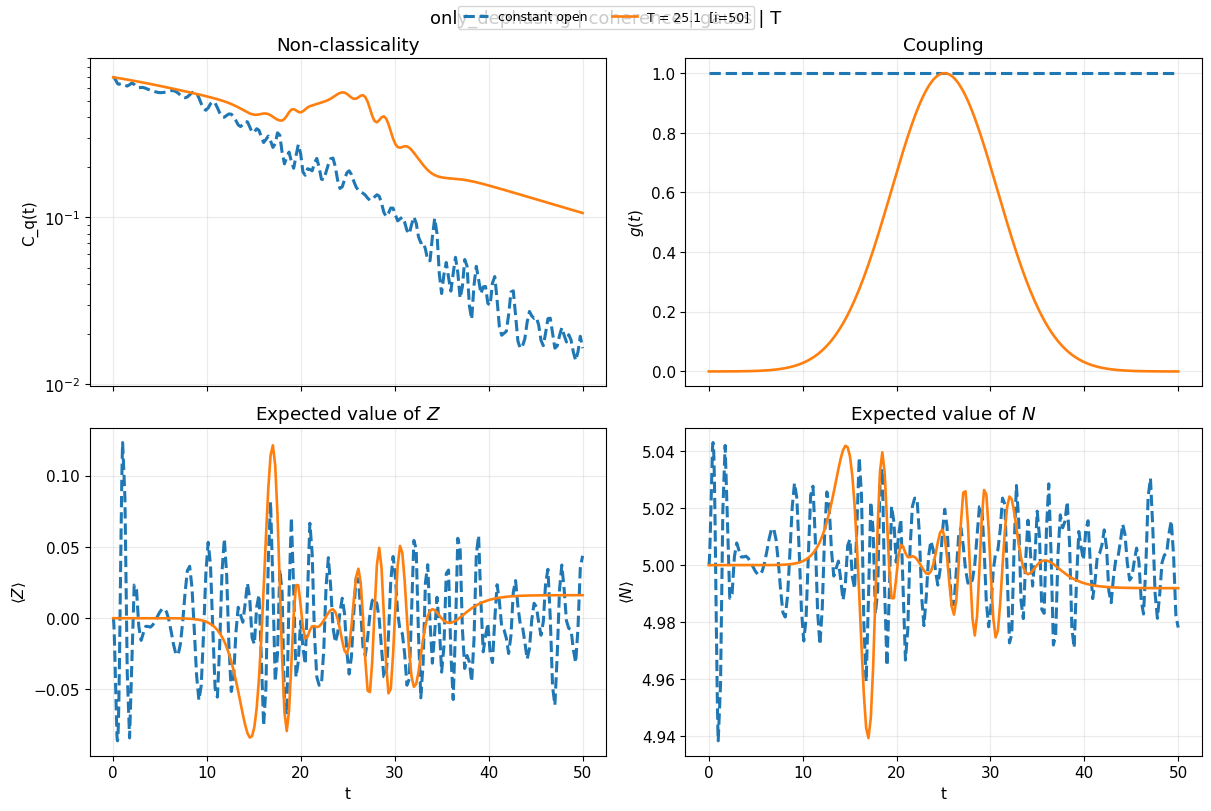

{'case_id': 'only_dephasing_coherence_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_coherence_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_coherence_gauss_T.pdf'}

In [11]:
plot_case_from_cell("only_dephasing_coherence_gauss_T")

## Coherence — Cosine frequency / omega

`only_dephasing_coherence_cos_omega`

case_id = only_dephasing_coherence_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_omega_0p157868977567,omega = 0.1579 [i=50],variable,50,51,0.157869
2,var_aberto_0100_omega_0p315737955135,omega = 0.3157 [i=100],variable,100,101,0.315738


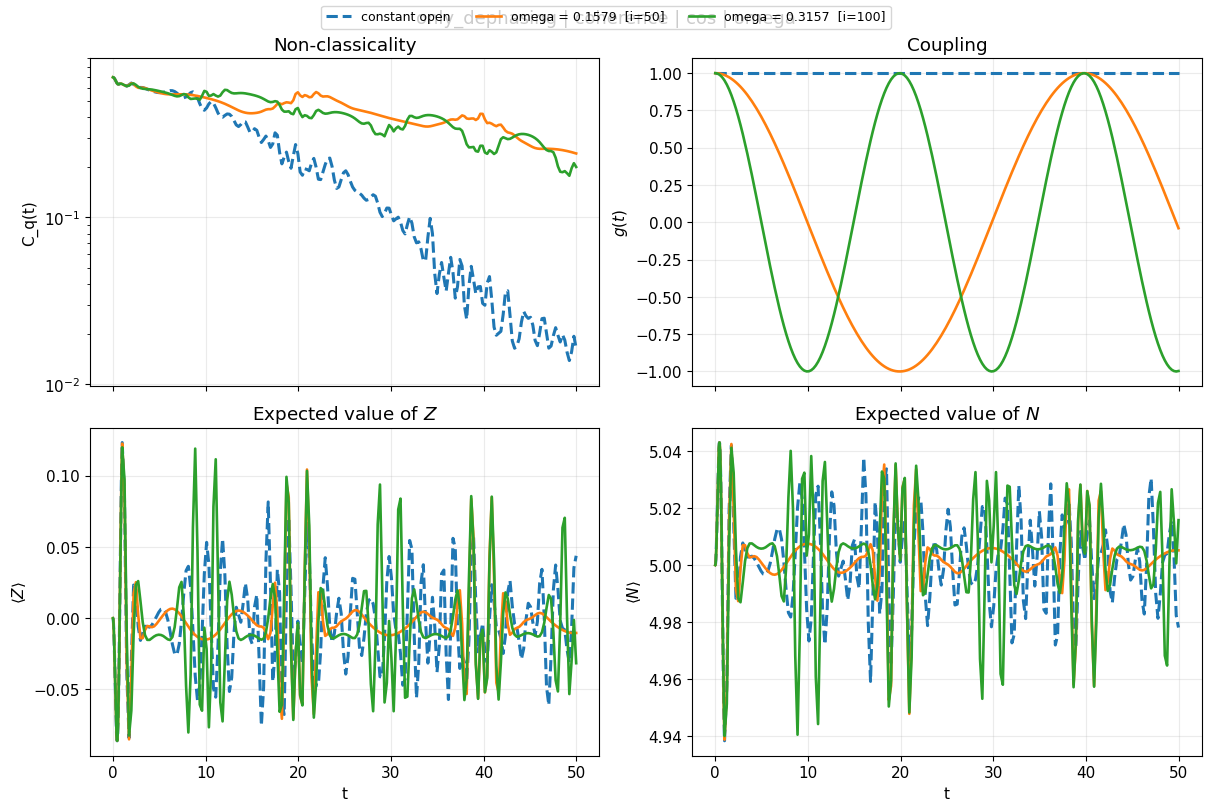

{'case_id': 'only_dephasing_coherence_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_coherence_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_coherence_cos_omega.pdf'}

In [12]:
plot_case_from_cell("only_dephasing_coherence_cos_omega")

## Magic — Gaussian width / zeta

`only_dephasing_magic_gauss_zeta`

case_id = only_dephasing_magic_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_zeta_8p0202020202,zeta = 8.02 [i=50],variable,50,51,8.020202


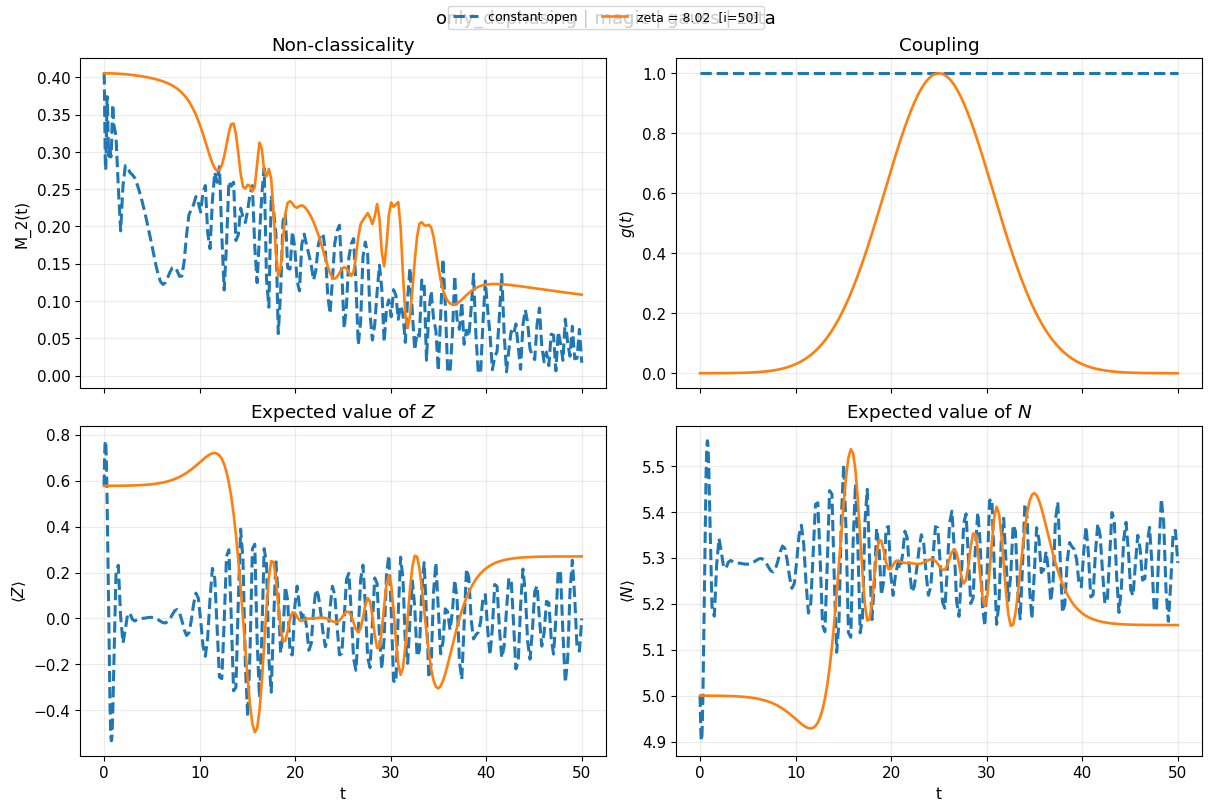

{'case_id': 'only_dephasing_magic_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_magic_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_magic_gauss_zeta.pdf'}

In [13]:
plot_case_from_cell("only_dephasing_magic_gauss_zeta")

## Magic — Gaussian peak time / T

`only_dephasing_magic_gauss_T`

case_id = only_dephasing_magic_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_25p101010101,T = 25.1 [i=50],variable,50,51,25.10101


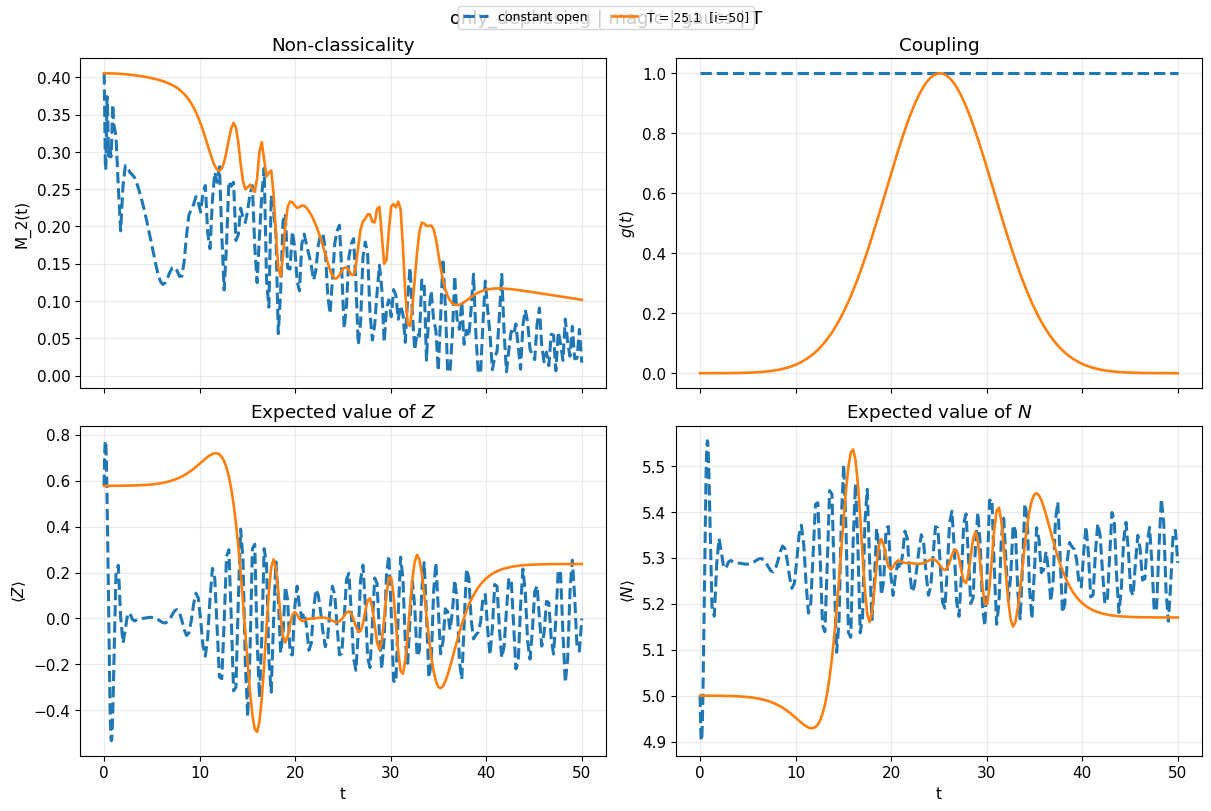

{'case_id': 'only_dephasing_magic_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_magic_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_magic_gauss_T.pdf'}

In [14]:
plot_case_from_cell("only_dephasing_magic_gauss_T")

## Magic — Cosine frequency / omega

`only_dephasing_magic_cos_omega`

case_id = only_dephasing_magic_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_omega_0p157868977567,omega = 0.1579 [i=50],variable,50,51,0.157869
2,var_aberto_0100_omega_0p315737955135,omega = 0.3157 [i=100],variable,100,101,0.315738


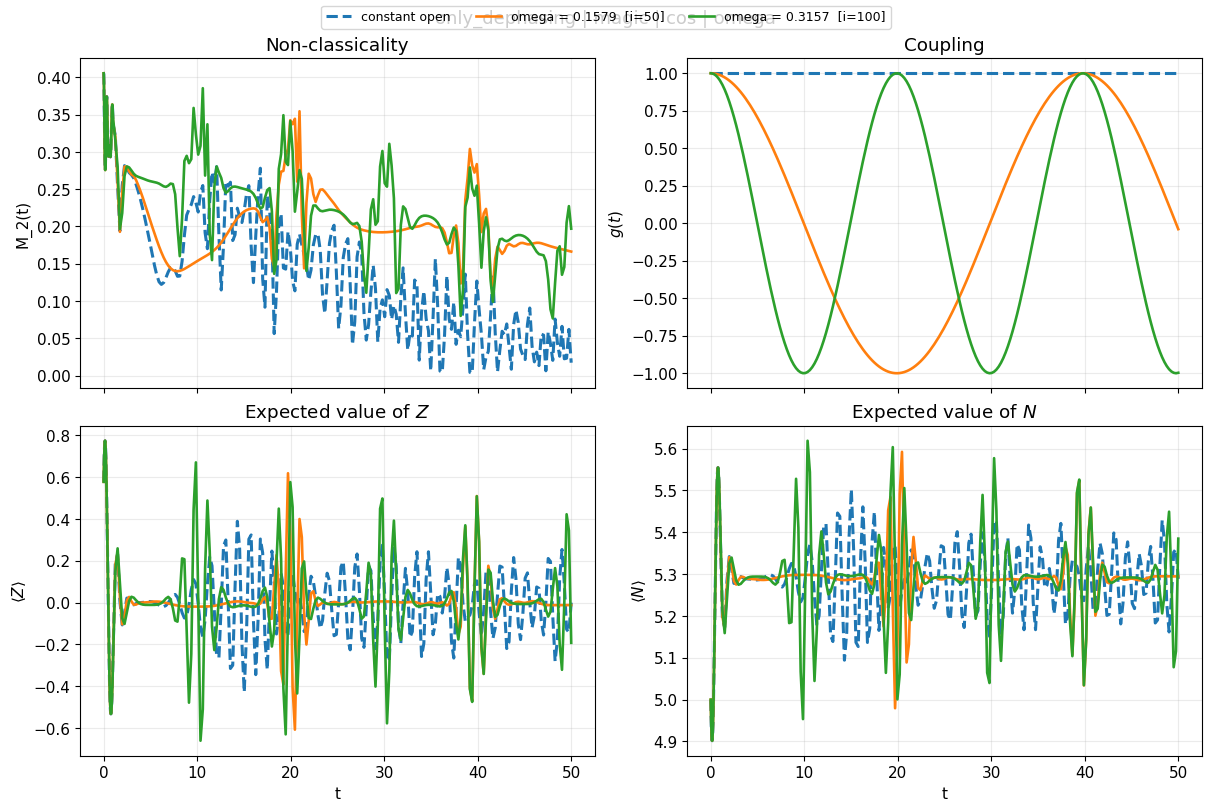

{'case_id': 'only_dephasing_magic_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_magic_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_magic_cos_omega.pdf'}

In [15]:
plot_case_from_cell("only_dephasing_magic_cos_omega")

## Entanglement — Gaussian width / zeta

`only_dephasing_entanglement_gauss_zeta`

case_id = only_dephasing_entanglement_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_zeta_8p0202020202,zeta = 8.02 [i=50],variable,50,51,8.020202


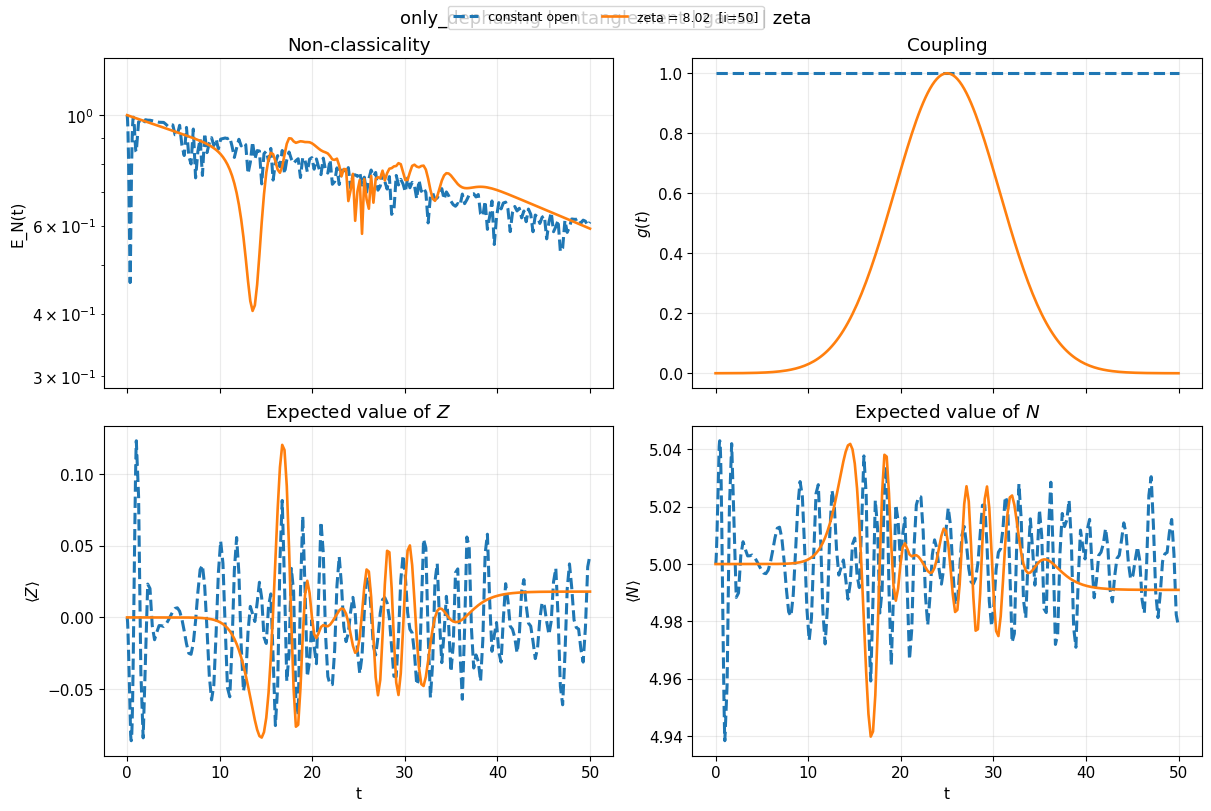

{'case_id': 'only_dephasing_entanglement_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_entanglement_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_entanglement_gauss_zeta.pdf'}

In [16]:
plot_case_from_cell("only_dephasing_entanglement_gauss_zeta")

## Entanglement — Gaussian peak time / T

`only_dephasing_entanglement_gauss_T`

case_id = only_dephasing_entanglement_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_25p101010101,T = 25.1 [i=50],variable,50,51,25.10101


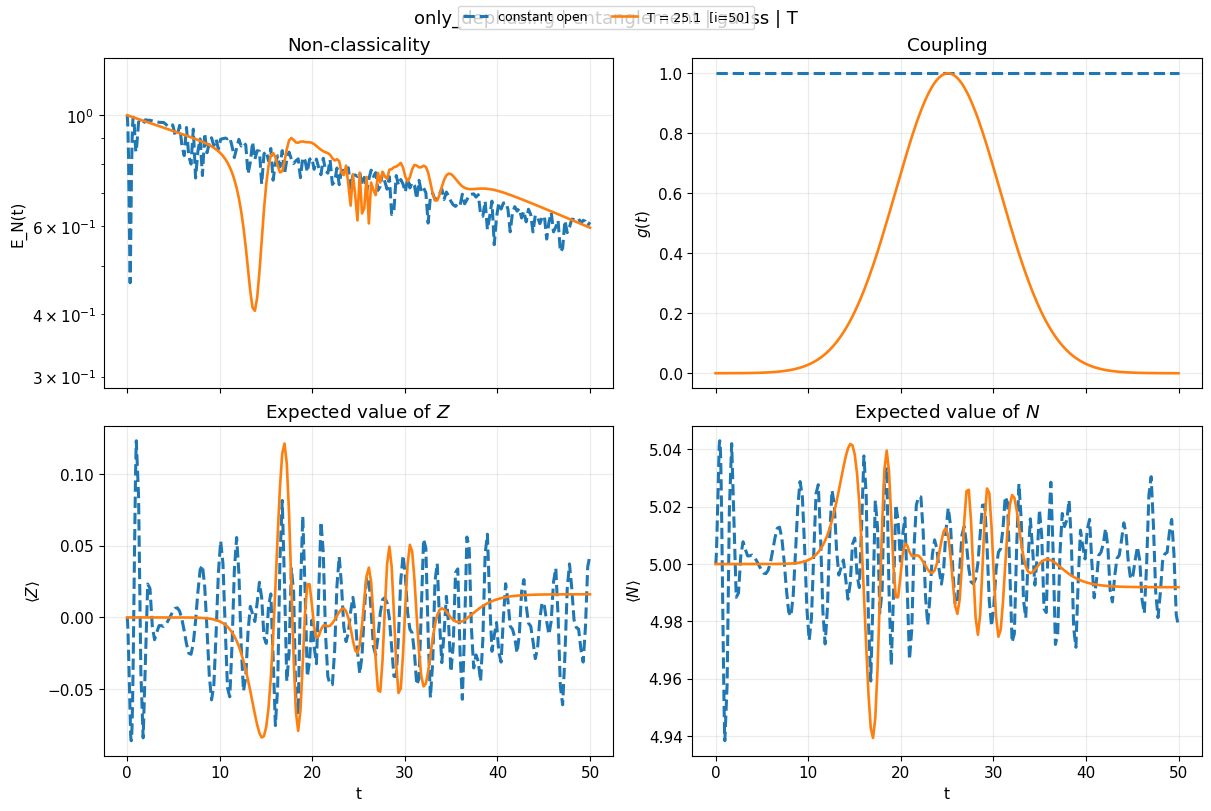

{'case_id': 'only_dephasing_entanglement_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_entanglement_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_entanglement_gauss_T.pdf'}

In [17]:
plot_case_from_cell("only_dephasing_entanglement_gauss_T")

## Entanglement — Cosine frequency / omega

`only_dephasing_entanglement_cos_omega`

case_id = only_dephasing_entanglement_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_omega_0p157868977567,omega = 0.1579 [i=50],variable,50,51,0.157869
2,var_aberto_0100_omega_0p315737955135,omega = 0.3157 [i=100],variable,100,101,0.315738


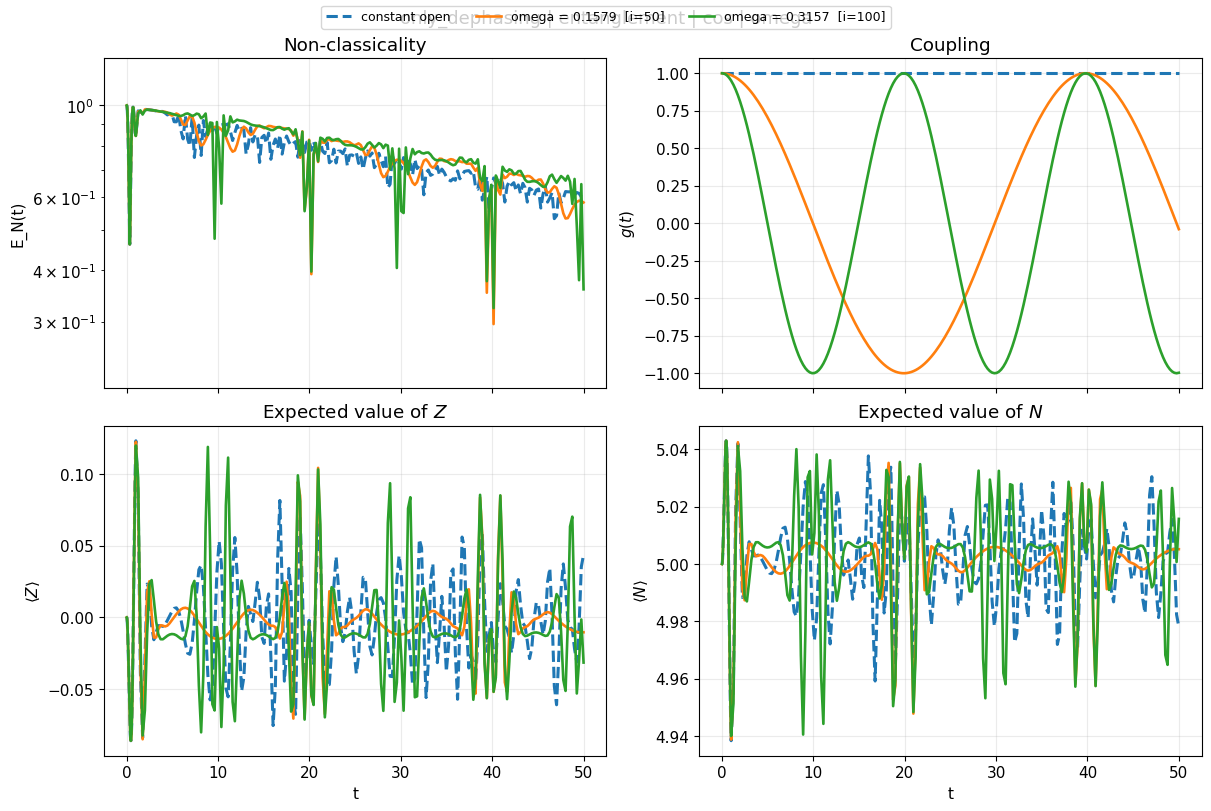

{'case_id': 'only_dephasing_entanglement_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_entanglement_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_dephasing_entanglement_cos_omega.pdf'}

In [18]:
plot_case_from_cell("only_dephasing_entanglement_cos_omega")

# Only cavity damping

$\kappa = 1e-2$, `gamma_phi = 0`, `g0 = 1`.

## Wigner — Gaussian width / zeta

`only_cavity_damping_wigner_gauss_zeta`

case_id = only_cavity_damping_wigner_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0125_zeta_2p40240963855,zeta = 2.402 [i=125],variable,125,126,2.40241


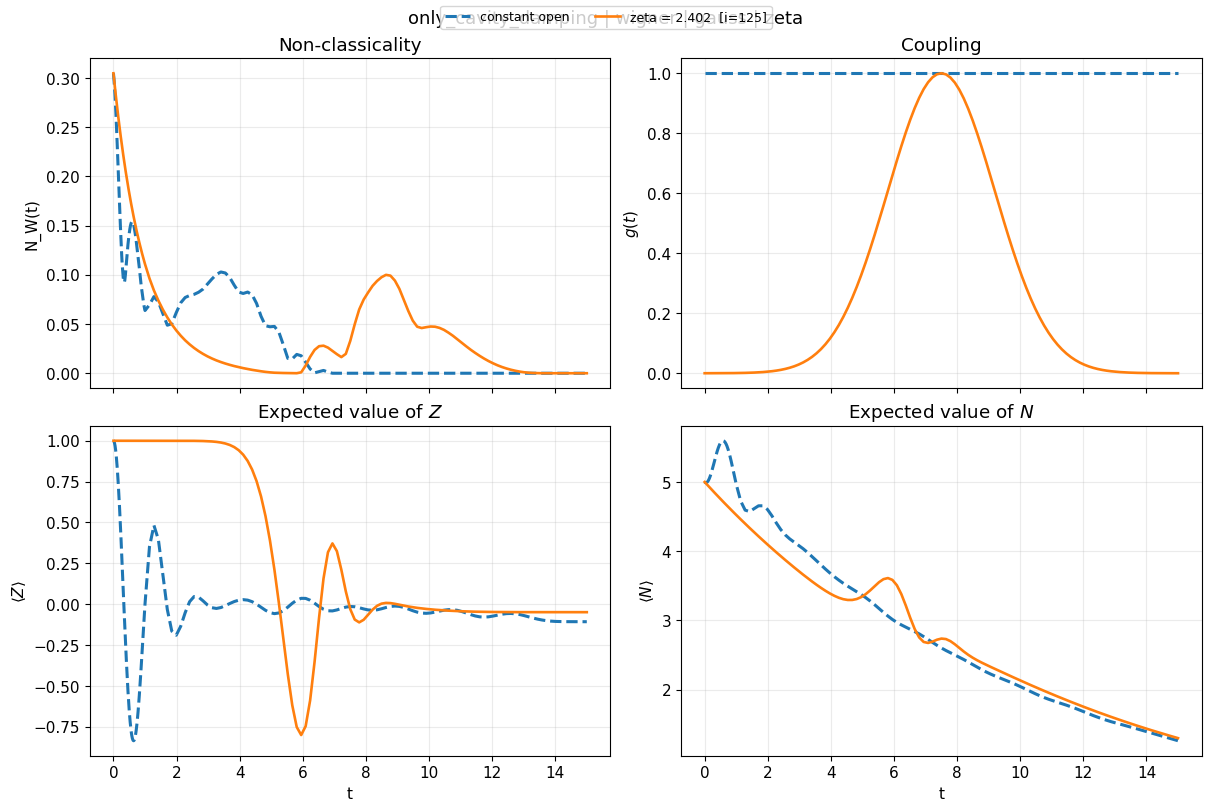

{'case_id': 'only_cavity_damping_wigner_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_wigner_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_wigner_gauss_zeta.pdf'}

In [19]:
plot_case_from_cell("only_cavity_damping_wigner_gauss_zeta")

## Wigner — Gaussian peak time / T

`only_cavity_damping_wigner_gauss_T`

case_id = only_cavity_damping_wigner_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_7p5303030303,T = 7.53 [i=50],variable,50,51,7.530303


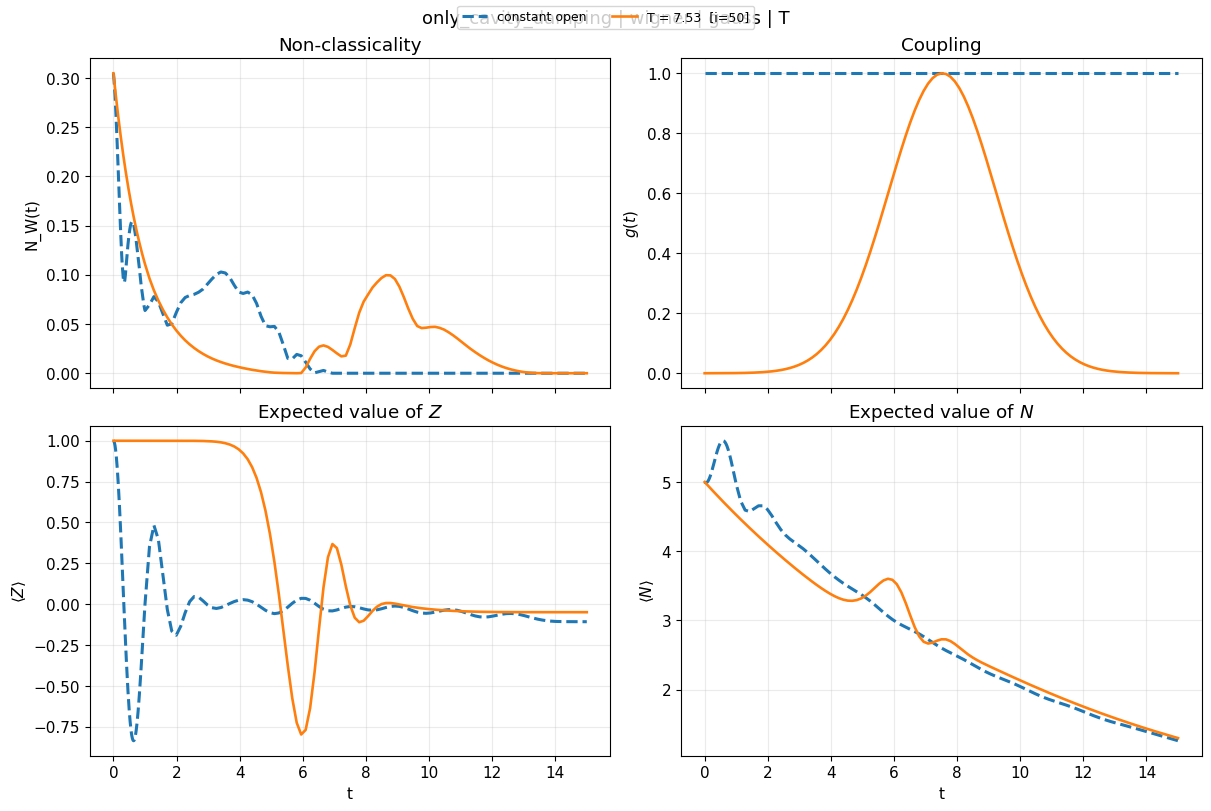

{'case_id': 'only_cavity_damping_wigner_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_wigner_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_wigner_gauss_T.pdf'}

In [20]:
plot_case_from_cell("only_cavity_damping_wigner_gauss_T")

## Wigner — Cosine frequency / omega

`only_cavity_damping_wigner_cos_omega`

case_id = only_cavity_damping_wigner_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0025_omega_0p528887652119,omega = 0.5289 [i=25],variable,25,26,0.528888
2,var_aberto_0050_omega_1p05777530424,omega = 1.058 [i=50],variable,50,51,1.057775


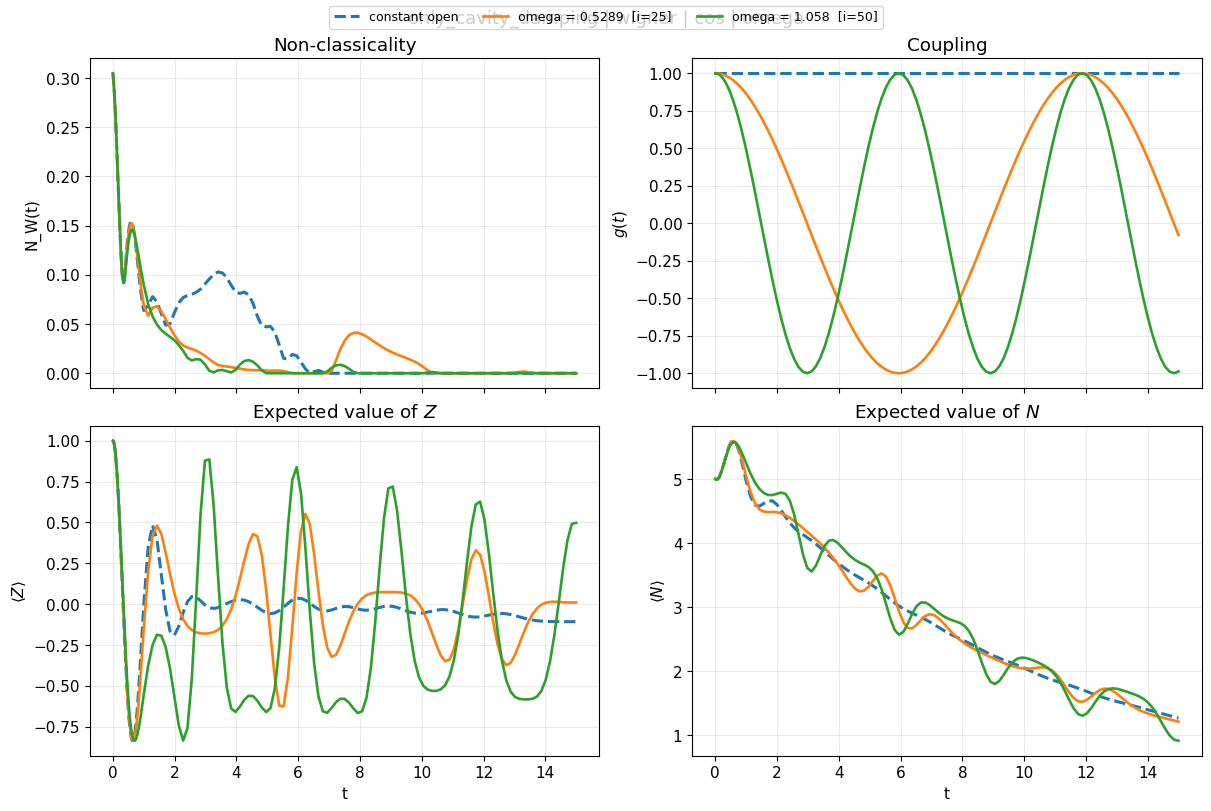

{'case_id': 'only_cavity_damping_wigner_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_wigner_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_wigner_cos_omega.pdf'}

In [21]:
plot_case_from_cell("only_cavity_damping_wigner_cos_omega")

## Coherence — Gaussian width / zeta

`only_cavity_damping_coherence_gauss_zeta`

case_id = only_cavity_damping_coherence_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_zeta_8p0202020202,zeta = 8.02 [i=50],variable,50,51,8.020202


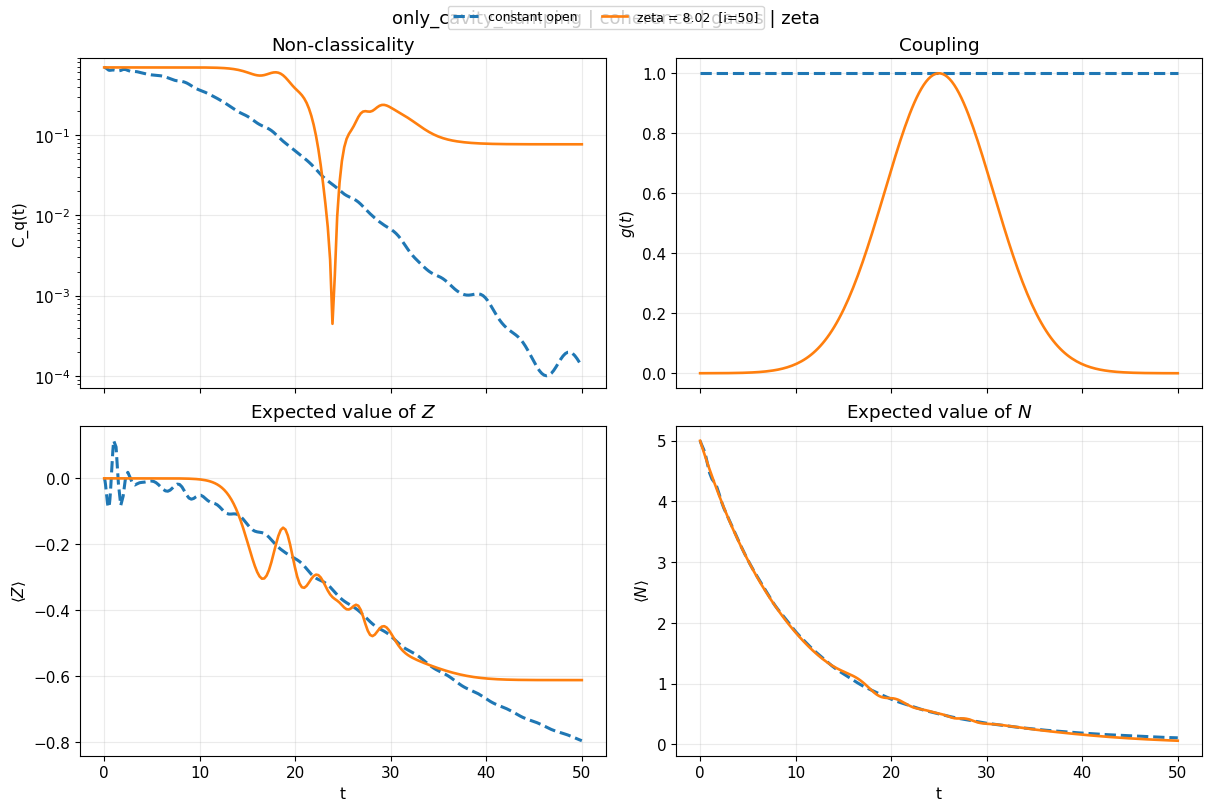

{'case_id': 'only_cavity_damping_coherence_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_coherence_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_coherence_gauss_zeta.pdf'}

In [22]:
plot_case_from_cell("only_cavity_damping_coherence_gauss_zeta")

## Coherence — Gaussian peak time / T

`only_cavity_damping_coherence_gauss_T`

case_id = only_cavity_damping_coherence_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_25p101010101,T = 25.1 [i=50],variable,50,51,25.10101


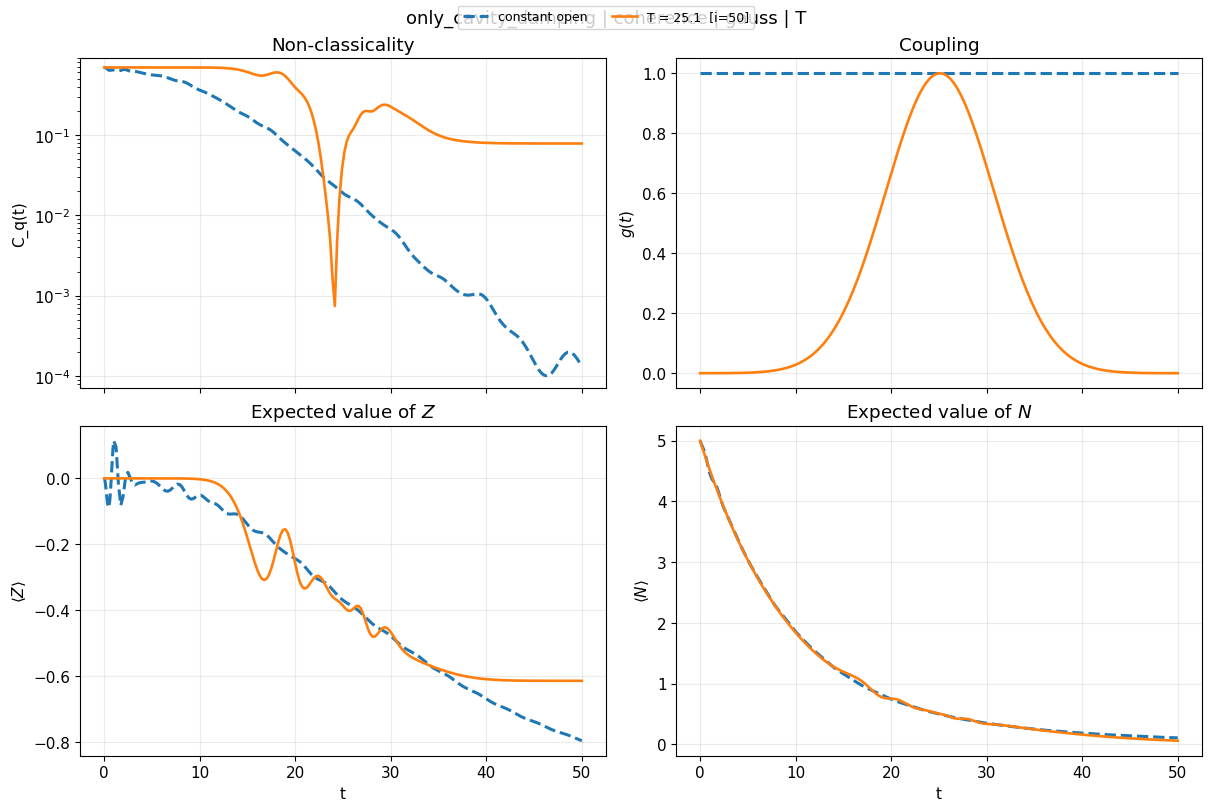

{'case_id': 'only_cavity_damping_coherence_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_coherence_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_coherence_gauss_T.pdf'}

In [23]:
plot_case_from_cell("only_cavity_damping_coherence_gauss_T")

## Coherence — Cosine frequency / omega

`only_cavity_damping_coherence_cos_omega`

case_id = only_cavity_damping_coherence_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_omega_0p157868977567,omega = 0.1579 [i=50],variable,50,51,0.157869
2,var_aberto_0100_omega_0p315737955135,omega = 0.3157 [i=100],variable,100,101,0.315738


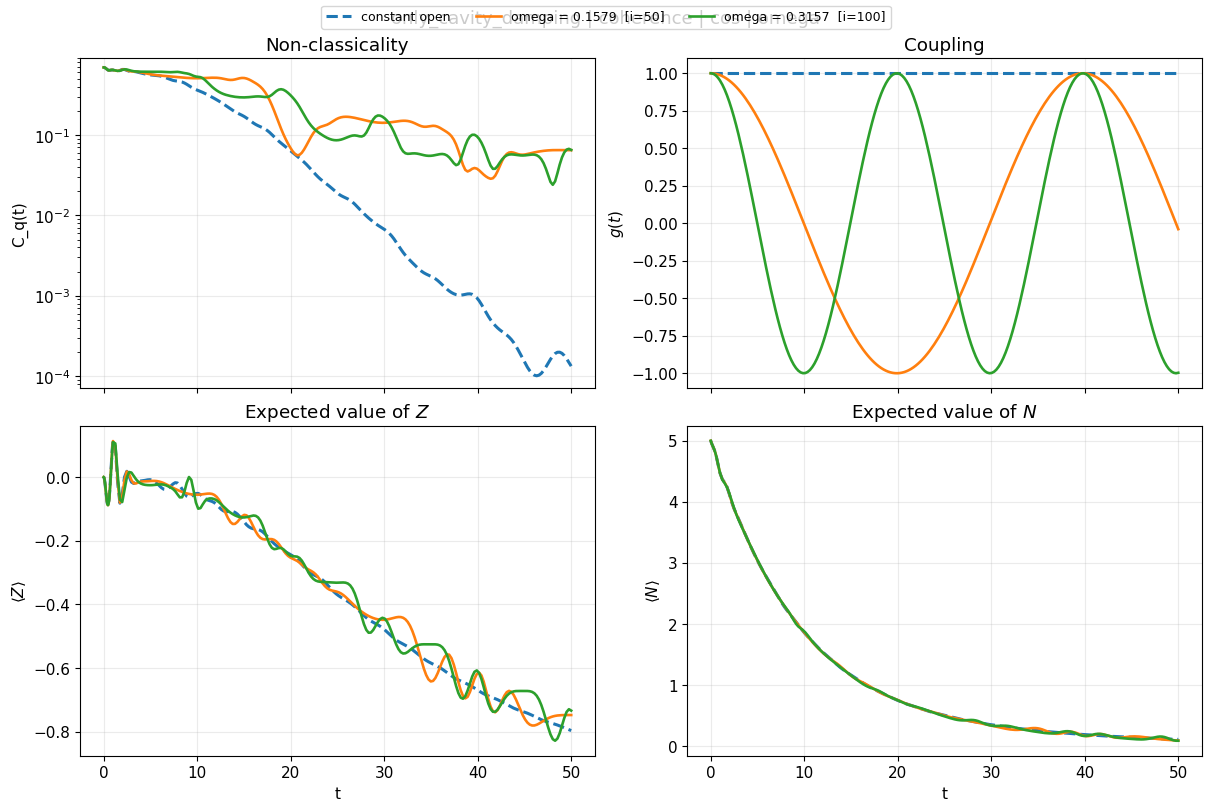

{'case_id': 'only_cavity_damping_coherence_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_coherence_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_coherence_cos_omega.pdf'}

In [24]:
plot_case_from_cell("only_cavity_damping_coherence_cos_omega")

## Magic — Gaussian width / zeta

`only_cavity_damping_magic_gauss_zeta`

case_id = only_cavity_damping_magic_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_zeta_8p0202020202,zeta = 8.02 [i=50],variable,50,51,8.020202


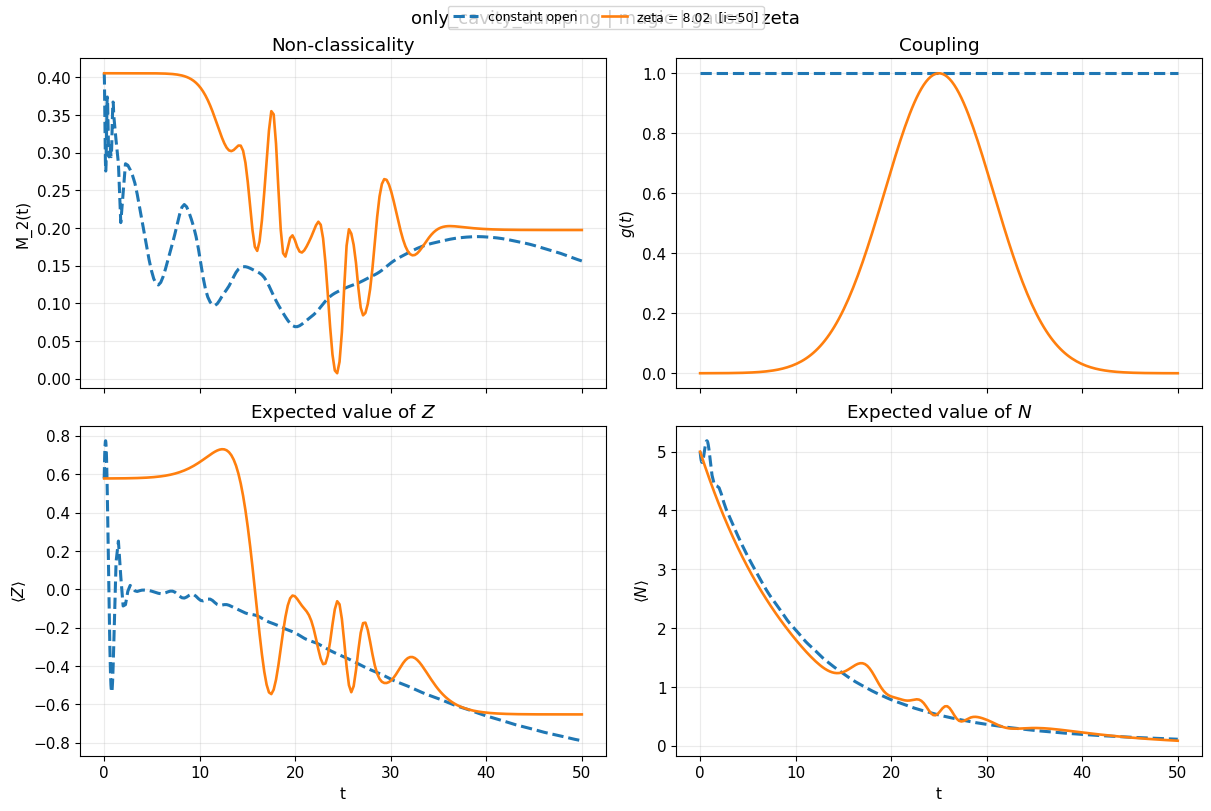

{'case_id': 'only_cavity_damping_magic_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_magic_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_magic_gauss_zeta.pdf'}

In [25]:
plot_case_from_cell("only_cavity_damping_magic_gauss_zeta")

## Magic — Gaussian peak time / T

`only_cavity_damping_magic_gauss_T`

case_id = only_cavity_damping_magic_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_25p101010101,T = 25.1 [i=50],variable,50,51,25.10101


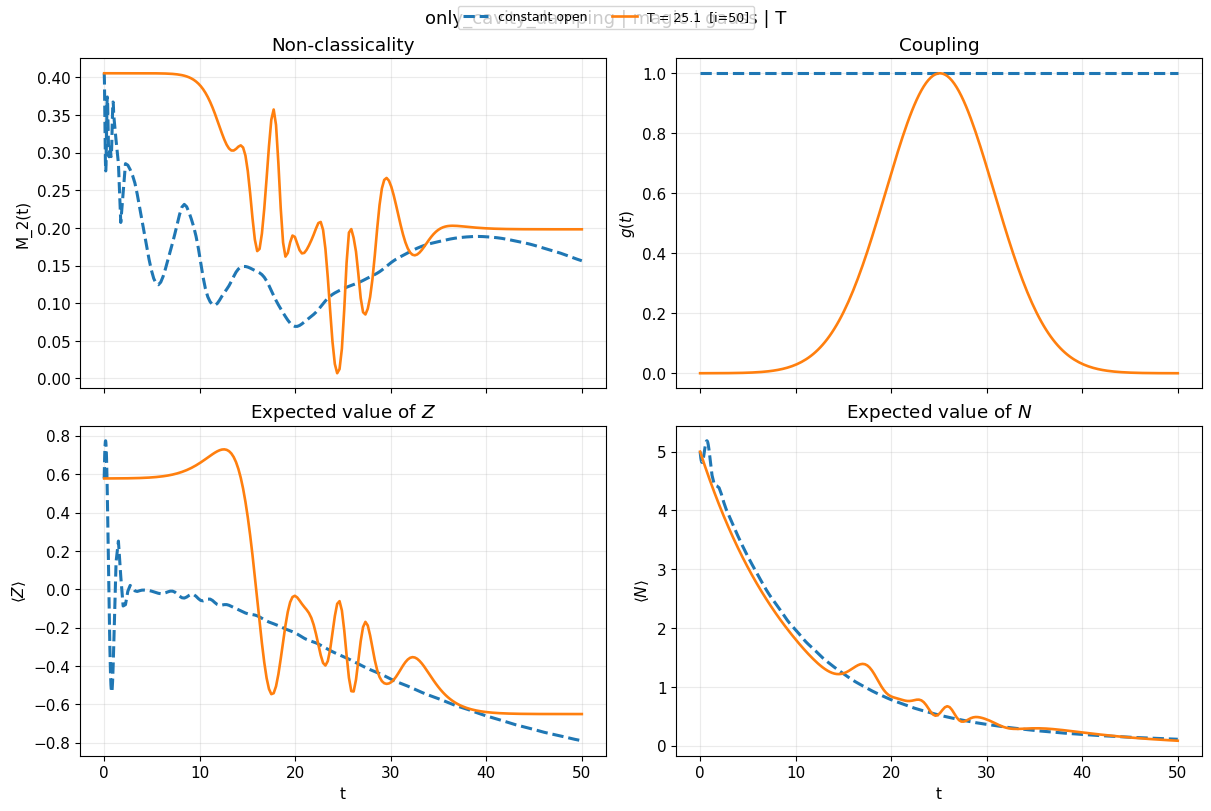

{'case_id': 'only_cavity_damping_magic_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_magic_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_magic_gauss_T.pdf'}

In [26]:
plot_case_from_cell("only_cavity_damping_magic_gauss_T")

## Magic — Cosine frequency / omega

`only_cavity_damping_magic_cos_omega`

case_id = only_cavity_damping_magic_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_omega_0p157868977567,omega = 0.1579 [i=50],variable,50,51,0.157869
2,var_aberto_0100_omega_0p315737955135,omega = 0.3157 [i=100],variable,100,101,0.315738


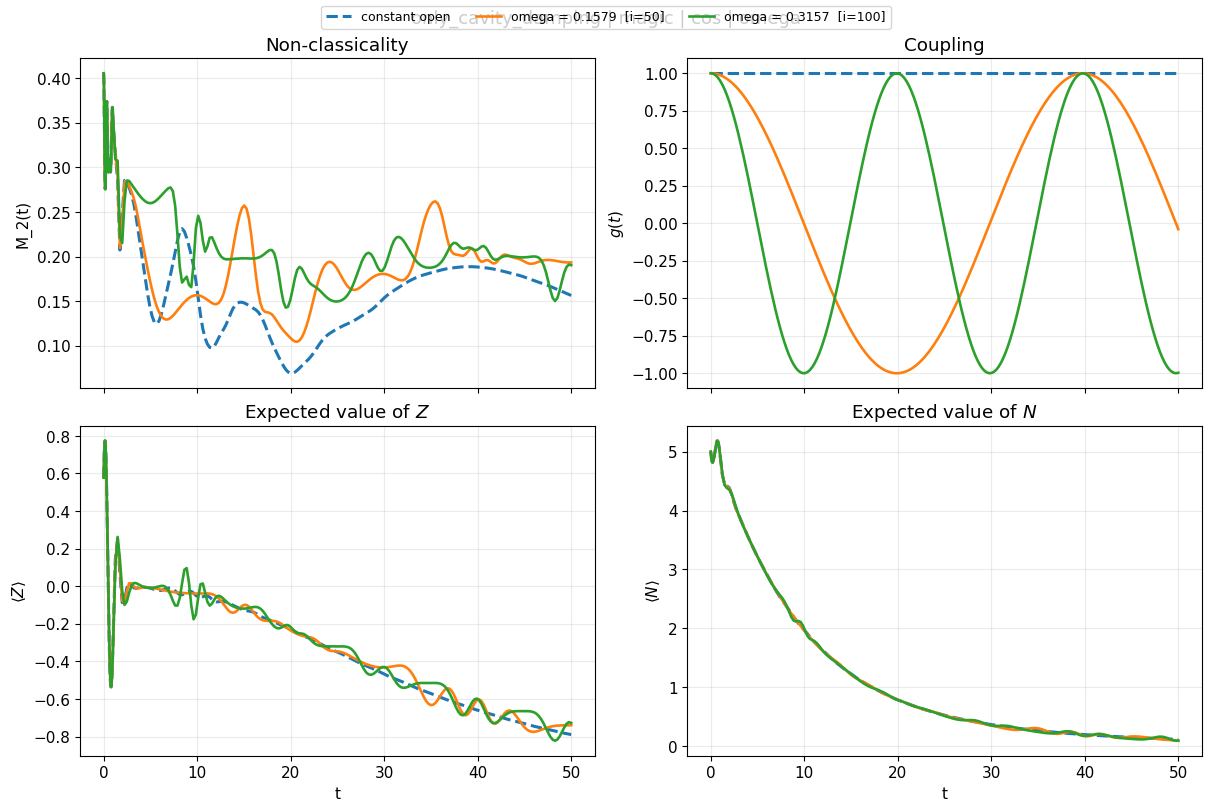

{'case_id': 'only_cavity_damping_magic_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_magic_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_magic_cos_omega.pdf'}

In [27]:
plot_case_from_cell("only_cavity_damping_magic_cos_omega")

## Entanglement — Gaussian width / zeta

`only_cavity_damping_entanglement_gauss_zeta`

case_id = only_cavity_damping_entanglement_gauss_zeta


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_zeta_8p0202020202,zeta = 8.02 [i=50],variable,50,51,8.020202


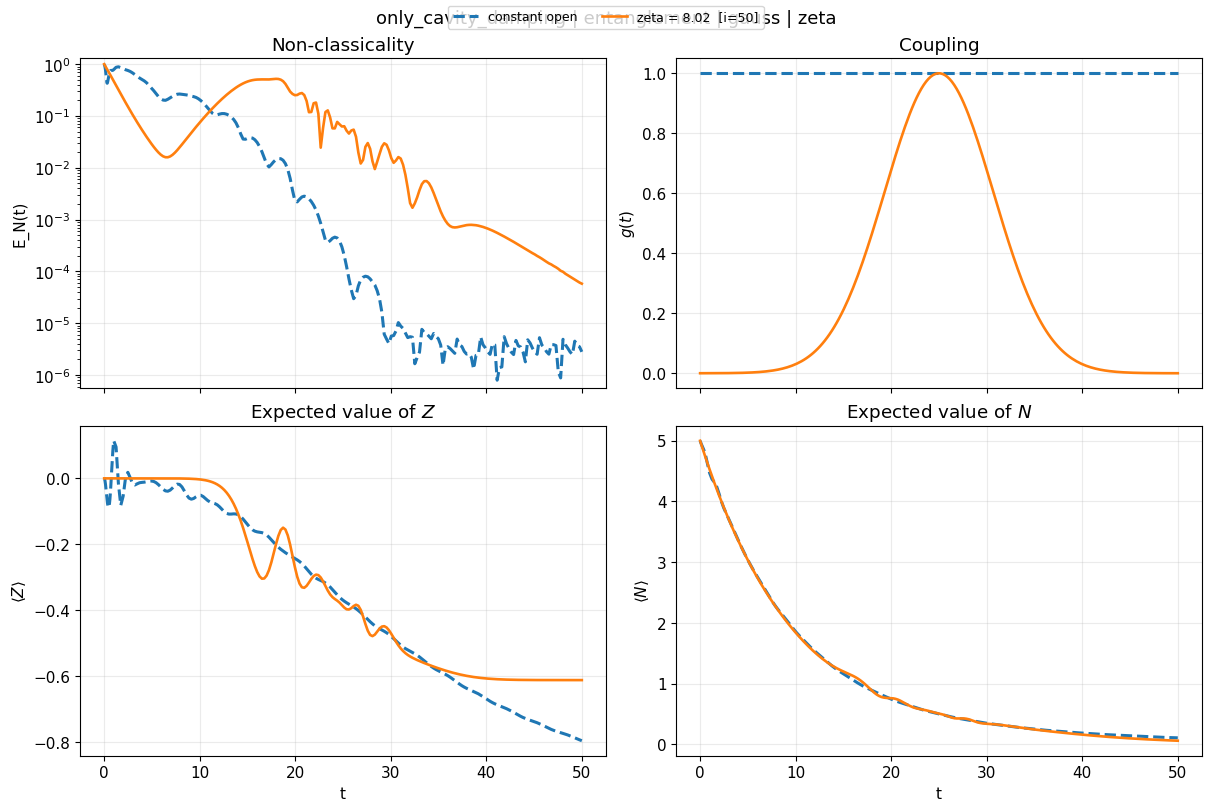

{'case_id': 'only_cavity_damping_entanglement_gauss_zeta',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_entanglement_gauss_zeta.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_entanglement_gauss_zeta.pdf'}

In [28]:
plot_case_from_cell("only_cavity_damping_entanglement_gauss_zeta")

## Entanglement — Gaussian peak time / T

`only_cavity_damping_entanglement_gauss_T`

case_id = only_cavity_damping_entanglement_gauss_T


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_T_25p101010101,T = 25.1 [i=50],variable,50,51,25.10101


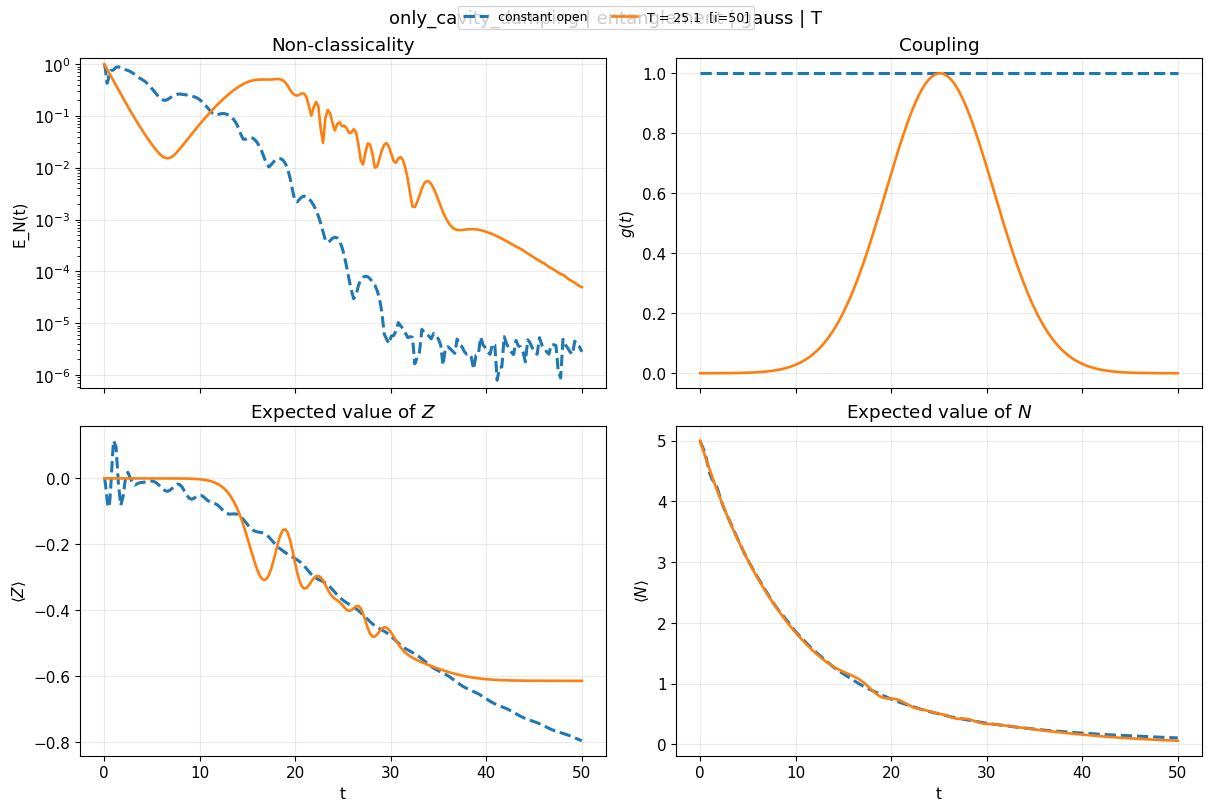

{'case_id': 'only_cavity_damping_entanglement_gauss_T',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_entanglement_gauss_T.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_entanglement_gauss_T.pdf'}

In [29]:
plot_case_from_cell("only_cavity_damping_entanglement_gauss_T")

## Entanglement — Cosine frequency / omega

`only_cavity_damping_entanglement_cos_omega`

case_id = only_cavity_damping_entanglement_cos_omega


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0050_omega_0p157868977567,omega = 0.1579 [i=50],variable,50,51,0.157869
2,var_aberto_0100_omega_0p315737955135,omega = 0.3157 [i=100],variable,100,101,0.315738


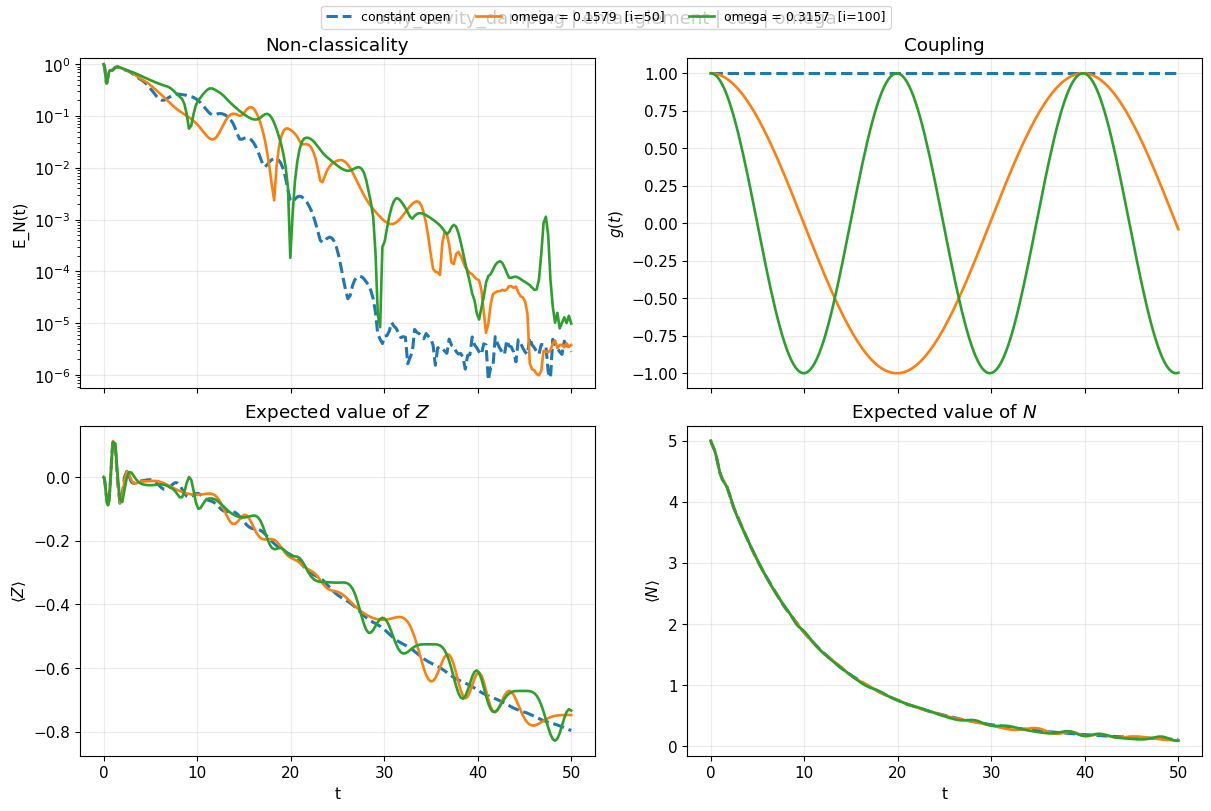

{'case_id': 'only_cavity_damping_entanglement_cos_omega',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_entanglement_cos_omega.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_only_cavity_damping_entanglement_cos_omega.pdf'}

In [30]:
plot_case_from_cell("only_cavity_damping_entanglement_cos_omega")

# Specific parameters

$\kappa = 1e-2$, dephasing em `gamma_phi = 1e-3`, `g0 = 1`; parâmetros específicos pedidos no PDF.

## Wigner — Gaussian width / zeta specific

`specific_parameters_wigner_gauss_zeta_specific`

case_id = specific_parameters_wigner_gauss_zeta_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_zeta_specific_2p4,zeta_specific = 2.4 [i=0],variable,0,1,2.4


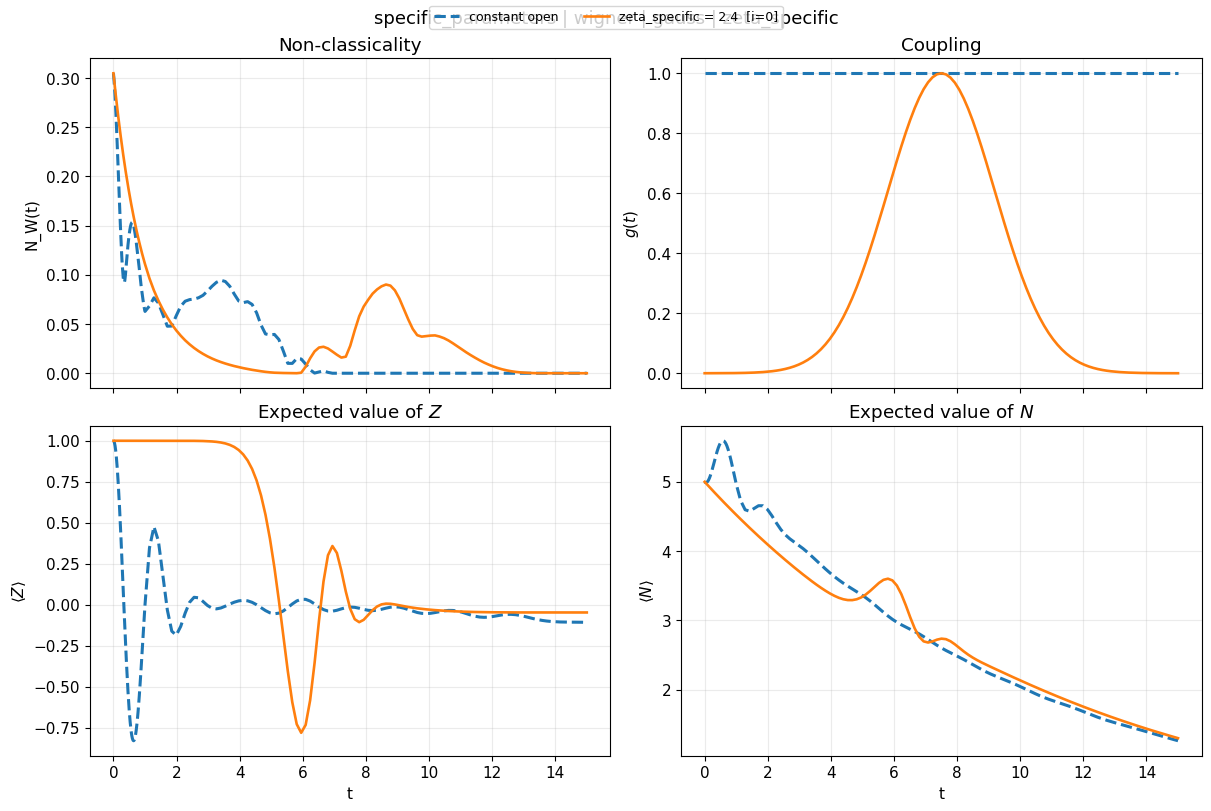

{'case_id': 'specific_parameters_wigner_gauss_zeta_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_wigner_gauss_zeta_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_wigner_gauss_zeta_specific.pdf'}

In [31]:
plot_case_from_cell("specific_parameters_wigner_gauss_zeta_specific")

## Wigner — Gaussian peak time / T specific

`specific_parameters_wigner_gauss_T_specific`

case_id = specific_parameters_wigner_gauss_T_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_T_specific_7p5,T_specific = 7.5 [i=0],variable,0,1,7.5


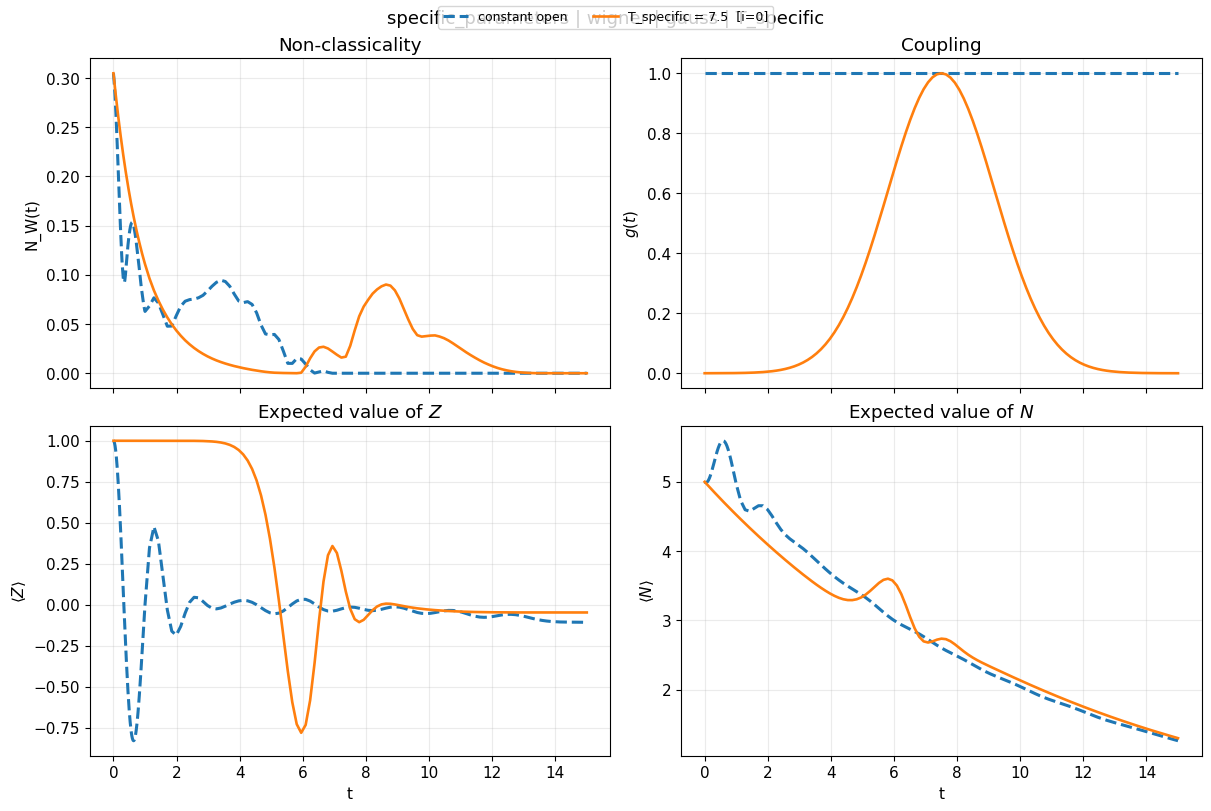

{'case_id': 'specific_parameters_wigner_gauss_T_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_wigner_gauss_T_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_wigner_gauss_T_specific.pdf'}

In [32]:
plot_case_from_cell("specific_parameters_wigner_gauss_T_specific")

## Wigner — Cosine frequency / omega specific

`specific_parameters_wigner_cos_omega_specific`

case_id = specific_parameters_wigner_cos_omega_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_omega_specific_0p523598775598,omega_specific = $\pi/6$ [i=0],variable,0,1,0.523599
2,var_aberto_0001_omega_specific_1p0471975512,omega_specific = $\pi/3$ [i=1],variable,1,2,1.047198


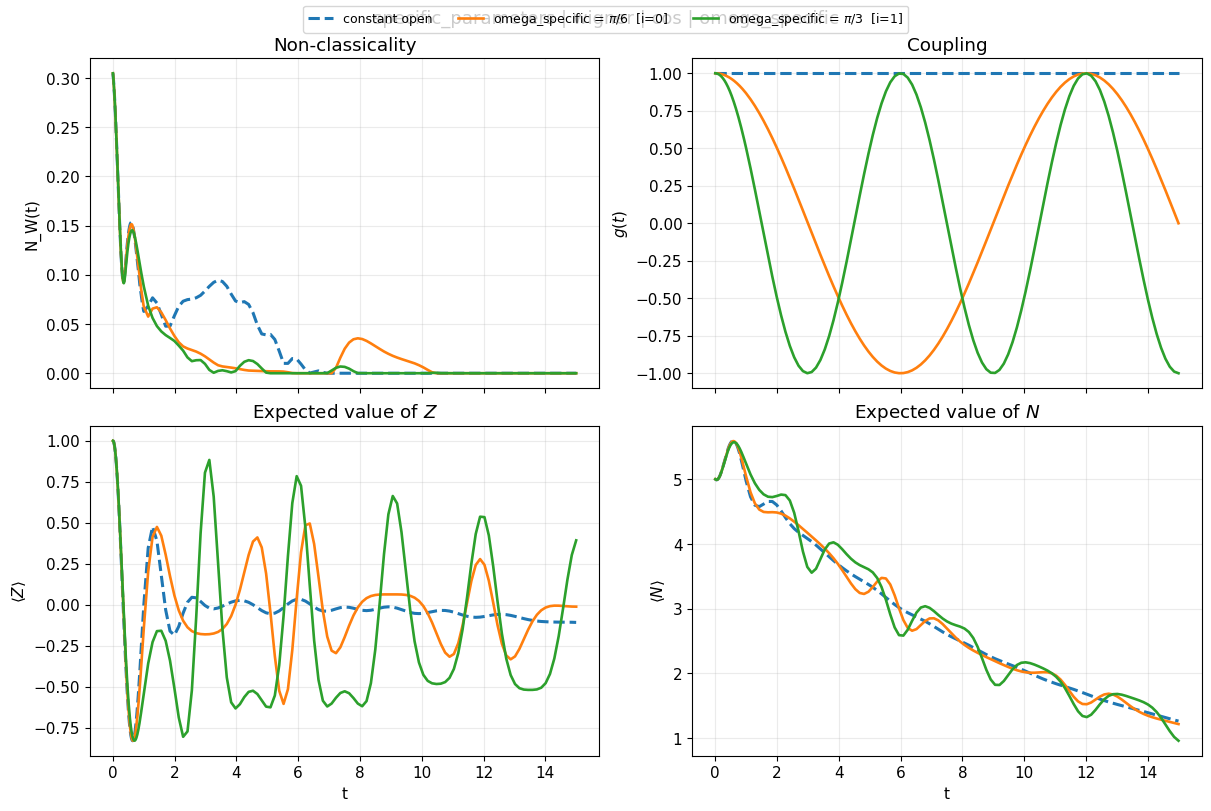

{'case_id': 'specific_parameters_wigner_cos_omega_specific',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_wigner_cos_omega_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_wigner_cos_omega_specific.pdf'}

In [33]:
plot_case_from_cell("specific_parameters_wigner_cos_omega_specific")

## Coherence — Gaussian width / zeta specific

`specific_parameters_coherence_gauss_zeta_specific`

case_id = specific_parameters_coherence_gauss_zeta_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_zeta_specific_8,zeta_specific = 8 [i=0],variable,0,1,8.0


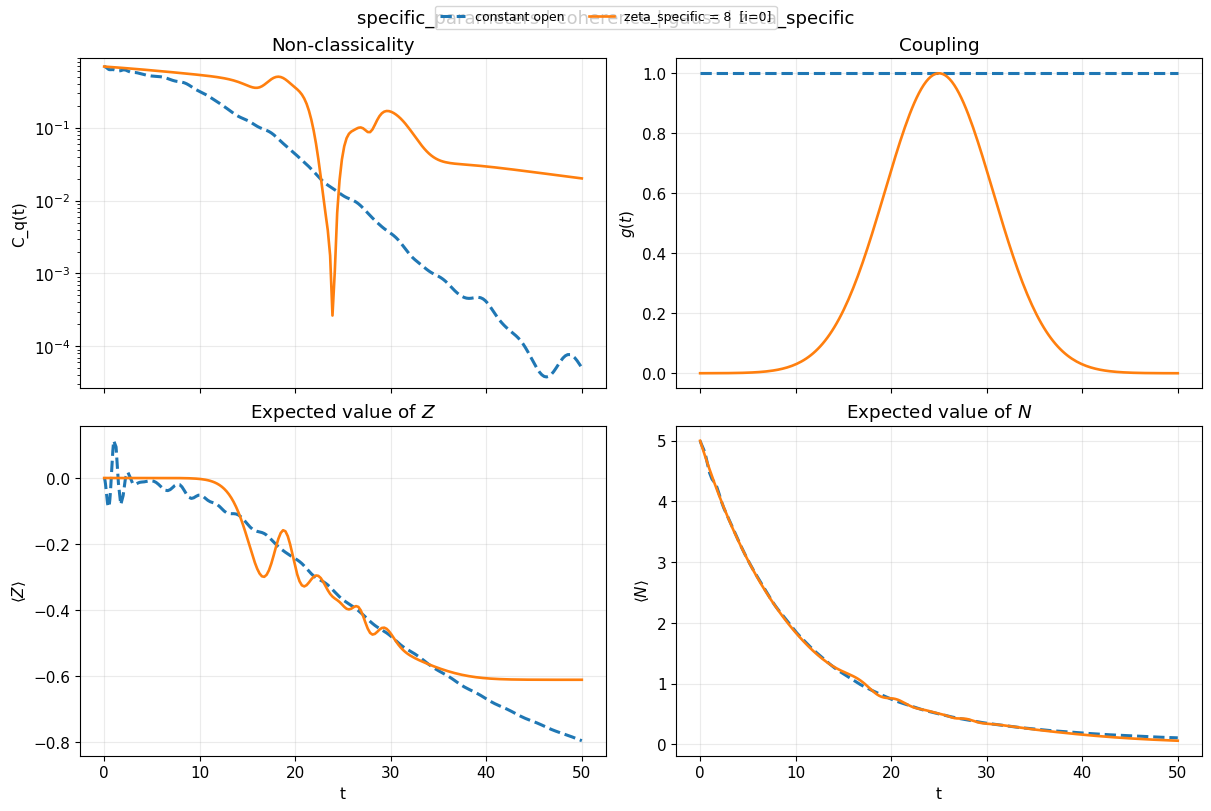

{'case_id': 'specific_parameters_coherence_gauss_zeta_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_coherence_gauss_zeta_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_coherence_gauss_zeta_specific.pdf'}

In [34]:
plot_case_from_cell("specific_parameters_coherence_gauss_zeta_specific")

## Coherence — Gaussian peak time / T specific

`specific_parameters_coherence_gauss_T_specific`

case_id = specific_parameters_coherence_gauss_T_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_T_specific_25,T_specific = 25 [i=0],variable,0,1,25.0


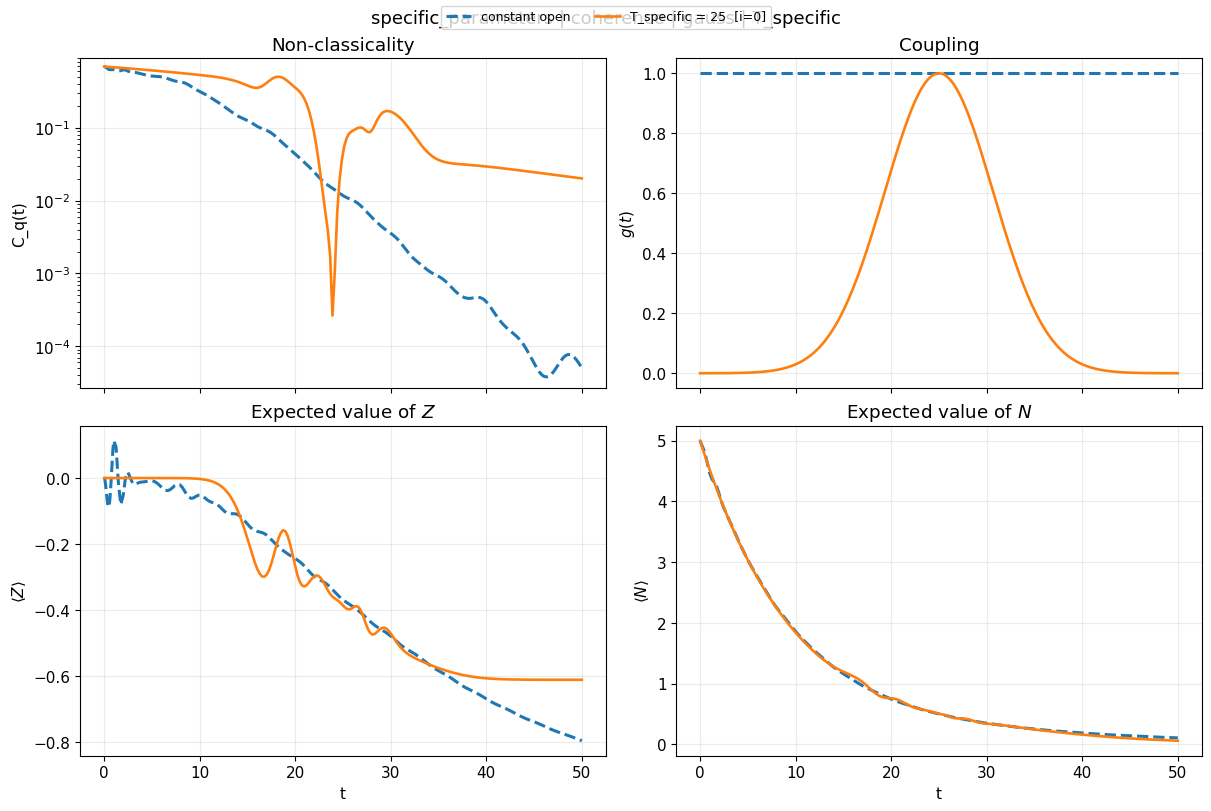

{'case_id': 'specific_parameters_coherence_gauss_T_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_coherence_gauss_T_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_coherence_gauss_T_specific.pdf'}

In [35]:
plot_case_from_cell("specific_parameters_coherence_gauss_T_specific")

## Coherence — Cosine frequency / omega specific

`specific_parameters_coherence_cos_omega_specific`

case_id = specific_parameters_coherence_cos_omega_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_omega_specific_0p157079632679,omega_specific = $\pi/20$ [i=0],variable,0,1,0.157080
2,var_aberto_0001_omega_specific_0p314159265359,omega_specific = $\pi/10$ [i=1],variable,1,2,0.314159


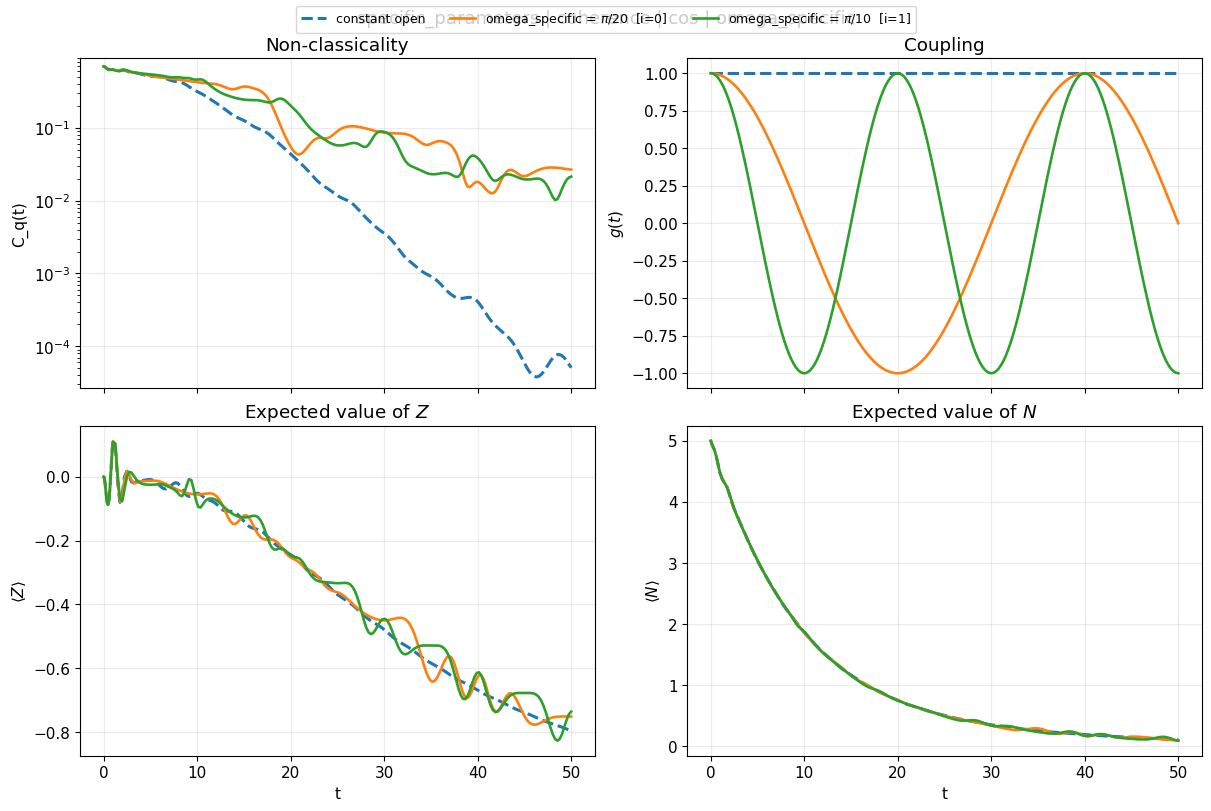

{'case_id': 'specific_parameters_coherence_cos_omega_specific',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_coherence_cos_omega_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_coherence_cos_omega_specific.pdf'}

In [36]:
plot_case_from_cell("specific_parameters_coherence_cos_omega_specific")

## Magic — Gaussian width / zeta specific

`specific_parameters_magic_gauss_zeta_specific`

case_id = specific_parameters_magic_gauss_zeta_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_zeta_specific_8,zeta_specific = 8 [i=0],variable,0,1,8.0


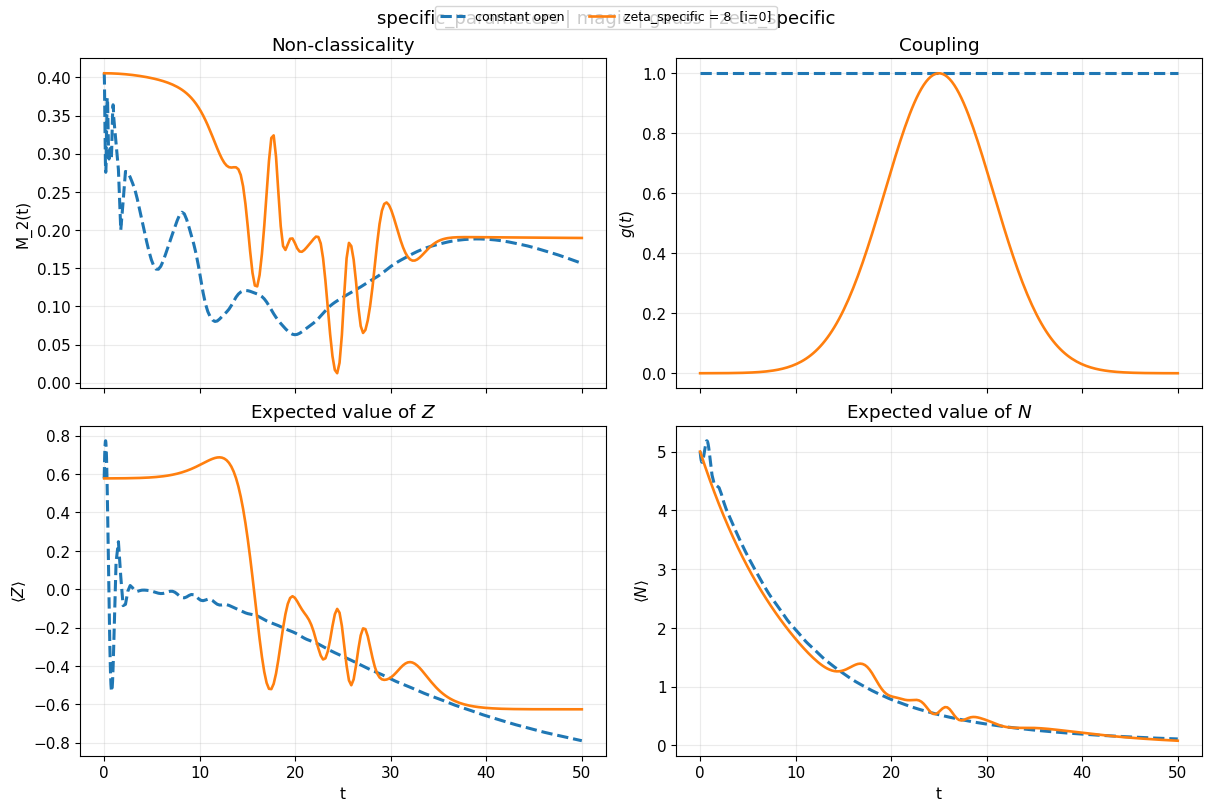

{'case_id': 'specific_parameters_magic_gauss_zeta_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_magic_gauss_zeta_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_magic_gauss_zeta_specific.pdf'}

In [37]:
plot_case_from_cell("specific_parameters_magic_gauss_zeta_specific")

## Magic — Gaussian peak time / T specific

`specific_parameters_magic_gauss_T_specific`

case_id = specific_parameters_magic_gauss_T_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_T_specific_25,T_specific = 25 [i=0],variable,0,1,25.0


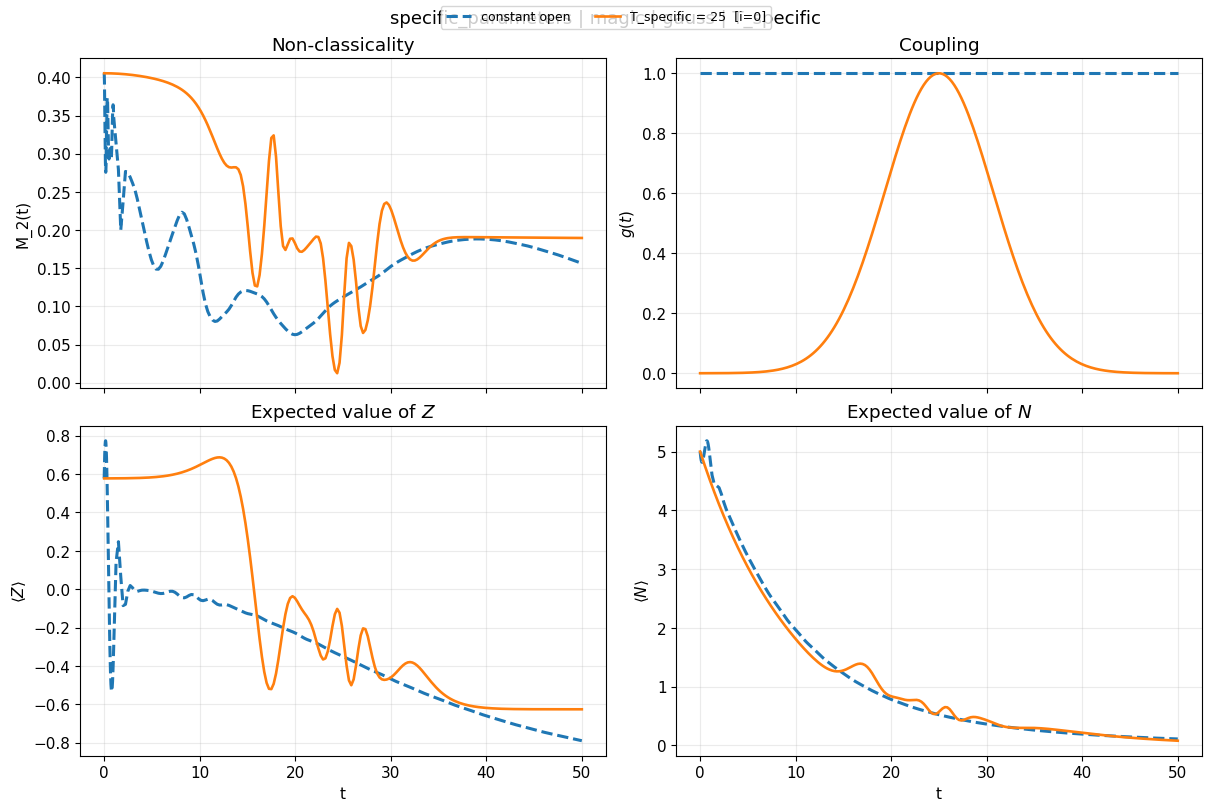

{'case_id': 'specific_parameters_magic_gauss_T_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_magic_gauss_T_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_magic_gauss_T_specific.pdf'}

In [38]:
plot_case_from_cell("specific_parameters_magic_gauss_T_specific")

## Magic — Cosine frequency / omega specific

`specific_parameters_magic_cos_omega_specific`

case_id = specific_parameters_magic_cos_omega_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_omega_specific_0p157079632679,omega_specific = $\pi/20$ [i=0],variable,0,1,0.157080
2,var_aberto_0001_omega_specific_0p314159265359,omega_specific = $\pi/10$ [i=1],variable,1,2,0.314159


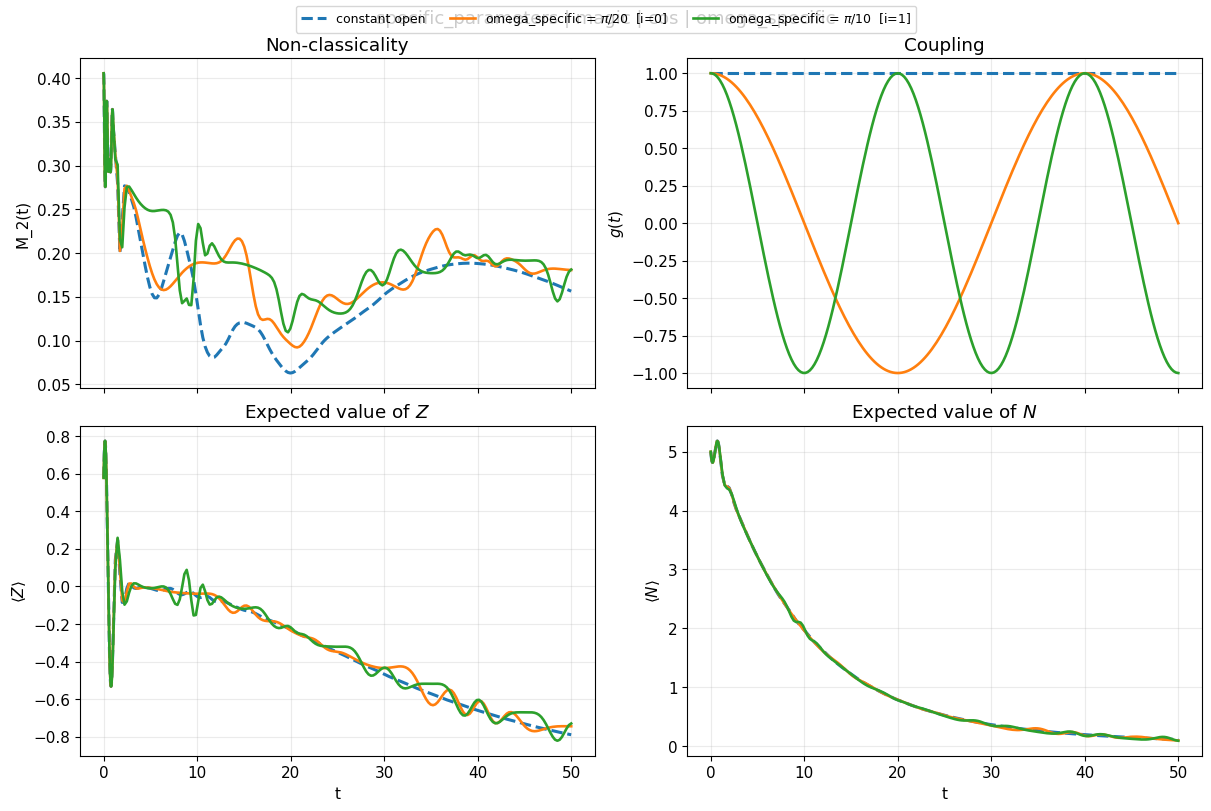

{'case_id': 'specific_parameters_magic_cos_omega_specific',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_magic_cos_omega_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_magic_cos_omega_specific.pdf'}

In [39]:
plot_case_from_cell("specific_parameters_magic_cos_omega_specific")

## Entanglement — Gaussian width / zeta specific

`specific_parameters_entanglement_gauss_zeta_specific`

case_id = specific_parameters_entanglement_gauss_zeta_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_zeta_specific_8,zeta_specific = 8 [i=0],variable,0,1,8.0


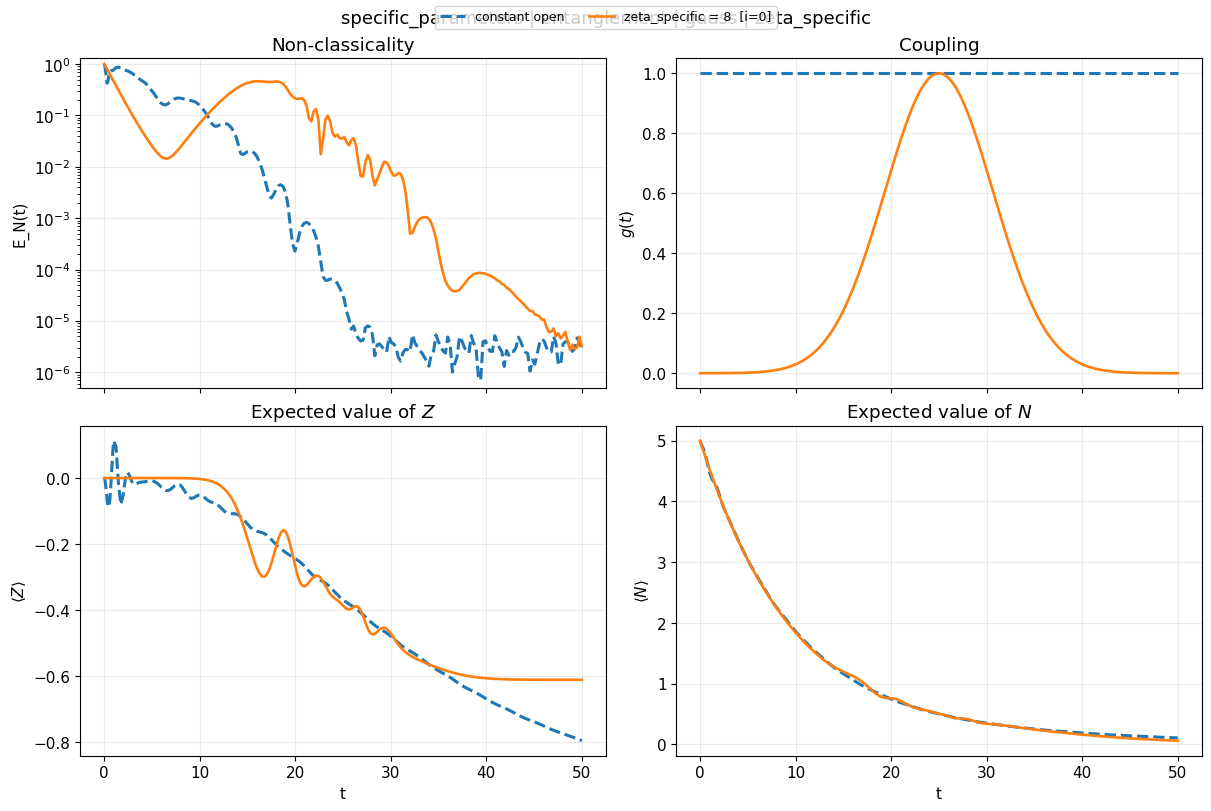

{'case_id': 'specific_parameters_entanglement_gauss_zeta_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_entanglement_gauss_zeta_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_entanglement_gauss_zeta_specific.pdf'}

In [40]:
plot_case_from_cell("specific_parameters_entanglement_gauss_zeta_specific")

## Entanglement — Gaussian peak time / T specific

`specific_parameters_entanglement_gauss_T_specific`

case_id = specific_parameters_entanglement_gauss_T_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_T_specific_25,T_specific = 25 [i=0],variable,0,1,25.0


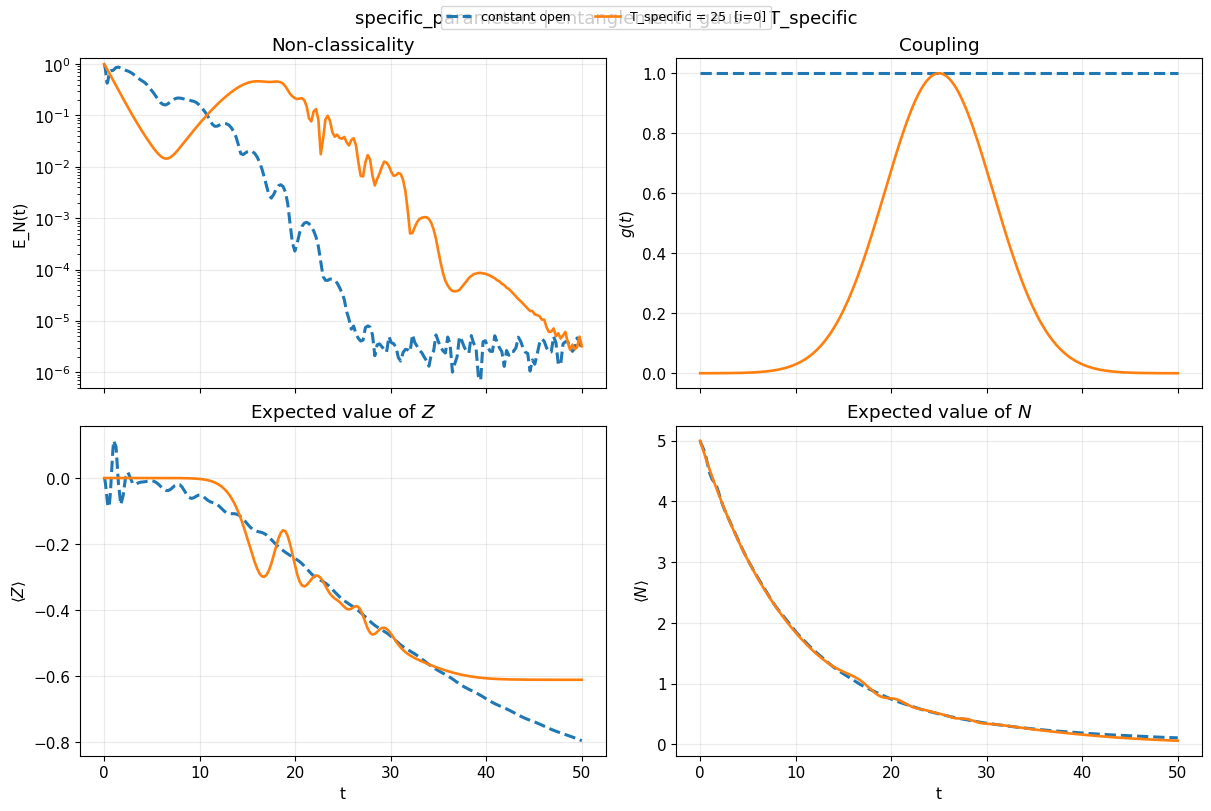

{'case_id': 'specific_parameters_entanglement_gauss_T_specific',
 'n_curves': 2,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_entanglement_gauss_T_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_entanglement_gauss_T_specific.pdf'}

In [41]:
plot_case_from_cell("specific_parameters_entanglement_gauss_T_specific")

## Entanglement — Cosine frequency / omega specific

`specific_parameters_entanglement_cos_omega_specific`

case_id = specific_parameters_entanglement_cos_omega_specific


,label,pretty,kind,scan_index_python,scan_index_text_1_based,scan_value
0,const_aberto,constant open,constant,-1,0,NaN
1,var_aberto_0000_omega_specific_0p157079632679,omega_specific = $\pi/20$ [i=0],variable,0,1,0.157080
2,var_aberto_0001_omega_specific_0p314159265359,omega_specific = $\pi/10$ [i=1],variable,1,2,0.314159


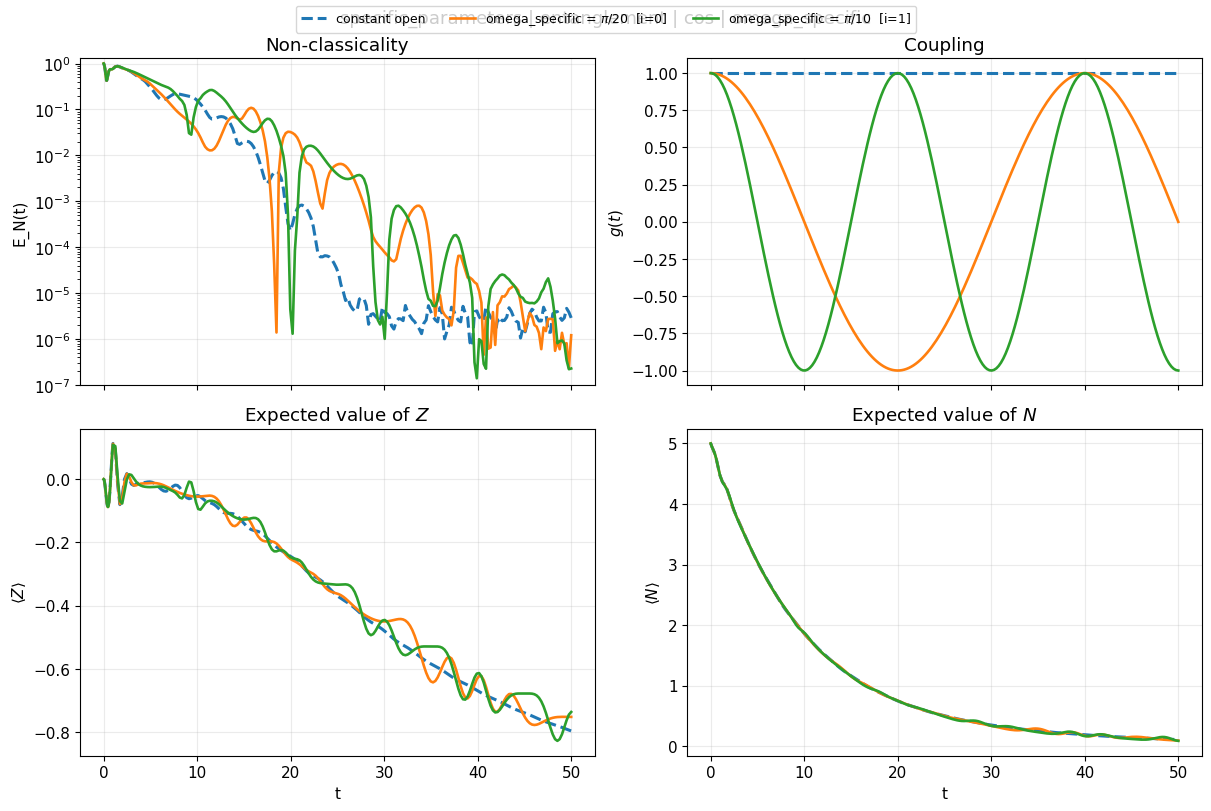

{'case_id': 'specific_parameters_entanglement_cos_omega_specific',
 'n_curves': 3,
 'files': 'results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_entanglement_cos_omega_specific.png;results/lista_simulacoes_open_system/open_system_sims1/figures_2x2_complete_notebook/plot_2x2_specific_parameters_entanglement_cos_omega_specific.pdf'}

In [42]:
plot_case_from_cell("specific_parameters_entanglement_cos_omega_specific")

# Diagnóstico final

Use esta célula depois de rodar tudo para ver quais casos ainda estão faltando ou incompletos.

In [43]:
diagnostic_rows = []
for cid in expected_case_ids:
    try:
        data = load_case(cid)
        rows = rows_to_plot(data)
        for row in rows:
            metric_path = os.path.join(data["folder"], f"{row['label']}.npy")
            obs_path = os.path.join(data["folder"], f"{row['label']}_observables.csv")
            diagnostic_rows.append({
                "case_id": cid,
                "label": row["label"],
                "metric_exists": os.path.exists(metric_path),
                "observables_exists": os.path.exists(obs_path),
            })
    except FileNotFoundError as exc:
        diagnostic_rows.append({
            "case_id": cid,
            "label": "CASE_FOLDER_OR_METADATA",
            "metric_exists": False,
            "observables_exists": False,
            "error": str(exc),
        })

diagnostic = pd.DataFrame(diagnostic_rows)
display(diagnostic)

if len(diagnostic) > 0:
    incomplete = diagnostic[(~diagnostic["metric_exists"]) | (~diagnostic["observables_exists"])]
    print("Linhas incompletas:", len(incomplete))
    if len(incomplete) > 0:
        display(incomplete)

,case_id,label,metric_exists,observables_exists
0,only_dephasing_wigner_gauss_zeta,const_aberto,True,True
1,only_dephasing_wigner_gauss_zeta,var_aberto_0125_zeta_2p40240963855,True,True
2,only_dephasing_wigner_gauss_T,const_aberto,True,True
3,only_dephasing_wigner_gauss_T,var_aberto_0050_T_7p5303030303,True,True
4,only_dephasing_wigner_cos_omega,const_aberto,True,True
...,...,...,...,...
79,specific_parameters_entanglement_gauss_T_specific,const_aberto,True,True
80,specific_parameters_entanglement_gauss_T_specific,var_aberto_0000_T_specific_25,True,True
81,specific_parameters_entanglement_cos_omega_spe...,const_aberto,True,True
82,specific_parameters_entanglement_cos_omega_spe...,var_aberto_0000_omega_specific_0p157079632679,True,True


Linhas incompletas: 0
